In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import KNeighborsClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

!pip install umap-learn


# 0. Import Datasets:

In [2]:
customers_db = pd.read_csv("datasets/customer_db_with_outliers.csv", sep=",", index_col=0)
flights_db = pd.read_csv("datasets/flights_db_with_outliers.csv", sep=",", index_col=0)

# Dataset Merging with Temporal Information Preservation

### Merging Strategy
We begin by aligning customer and flight datasets using `Loyalty#` as the common key. To ensure consistency and avoid join issues, the key is explicitly cast to an integer type in both datasets. A **left join** is then applied so that all customers are retained in the merged dataset, even if they have no associated flight records.

At this stage, the datasets are successfully merged at the record level, preserving all customer attributes alongside their corresponding flight entries.

---

### Problem: Loss of Temporal Granularity in Standard Merges
A straightforward merge is not sufficient when the data contains **time-dependent information**. Each customer can have multiple flight records across different months, and simply aggregating after a merge risks losing:
- Month-wise flight activity
- Seasonal and usage patterns
- Information about when a customer was active or inactive

In particular, `Year` and `Month` exist at the flight level, and without special handling, this temporal structure cannot be preserved in a single customer-level table.

---

### Solution: Explicit Year–Month Construction and Controlled Aggregation
To address this, a `YearMonth` feature is explicitly created in `YYYY-MM` format. This acts as a stable temporal key that allows us to:
- Track customer activity at a monthly resolution
- Aggregate flight data without collapsing the time dimension prematurely

Using this key, multiple controlled aggregations are performed:
- **Customer-level aggregation** to preserve static attributes and summarize overall flight behavior
- **Month-wise indicators and counts** to capture whether a customer flew in a given month and how frequently
- **Activity window features** to identify first activity, last activity, total active months, and recency

---

### Action Taken
- Performed a left merge to retain all customer records
- Created a `YearMonth` temporal key to preserve monthly flight information
- Aggregated customer attributes and flight metrics in a structured manner
- Generated additional tables to explicitly retain month-wise usage patterns
- Merged all components into a final customer-level dataset that preserves both **behavioral totals** and **temporal dynamics**

This approach ensures that no critical time-based information is lost during merging, while still producing a clean, model-ready customer table.
# 1. Merge Customer and Flight Data

In [3]:
customers_db['Loyalty#'] = customers_db['Loyalty#'].astype(int)
flights_db['Loyalty#'] = flights_db['Loyalty#'].astype(int)
customer_flights_combined = pd.merge(customers_db, flights_db, on='Loyalty#', how='left')
customer_flights_combined.columns.values

array(['Loyalty#', 'Customer Name', 'Province or State', 'City',
       'Latitude', 'Longitude', 'Postal code', 'Gender', 'Education',
       'Location Code', 'Income', 'Marital Status', 'LoyaltyStatus',
       'EnrollmentDateOpening', 'Customer Lifetime Value',
       'EnrollmentType', 'IsCancelled', 'Tenure_months', 'Year', 'Month',
       'YearMonthDate', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'avg_distance_per_flight',
       'companion_share'], dtype=object)

In [4]:
customer_flights_combined["YearMonth"] = (
    customer_flights_combined["Year"].astype(str)
    + "-"
    + customer_flights_combined["Month"].astype(str).str.zfill(2)
)

customer_agg = (
    customer_flights_combined
    .groupby("Loyalty#", as_index=False)
    .agg(
        customer_name=("Customer Name", "first"),
        province=("Province or State", "first"),
        city=("City", "first"),
        latitude=("Latitude", "first"),
        longitude=("Longitude", "first"),
        postal_code=("Postal code", "first"),
        gender=("Gender", "first"),
        education=("Education", "first"),
        location_code=("Location Code", "first"),
        income=("Income", "first"),
        marital_status=("Marital Status", "first"),
        loyalty_status=("LoyaltyStatus", "first"),
        enrollment_date=("EnrollmentDateOpening", "first"),
        enrollment_type=("EnrollmentType", "first"),
        customer_lifetime_value=("Customer Lifetime Value", "first"),
        is_cancelled=("IsCancelled", "max"),
        tenure_months=("Tenure_months", "max"),
        NumFlights=("NumFlights", "sum"),
        NumFlightsWithCompanions=("NumFlightsWithCompanions", "sum"),
        DistanceKM=("DistanceKM", "sum"),
        PointsAccumulated=("PointsAccumulated", "sum"),
        PointsRedeemed=("PointsRedeemed", "sum"),
        DollarCostPointsRedeemed=("DollarCostPointsRedeemed", "sum"),
    )
)


flights_count_ym = (
    customer_flights_combined
    .groupby(["Loyalty#", "YearMonth"])["NumFlights"]
    .sum()
    .unstack(fill_value=0)
    .add_prefix("flights_taken_")
    .reset_index()
)

usage_window = (
    customer_flights_combined
    .groupby("Loyalty#", as_index=False)
    .agg(
        last_active_month=("YearMonth", "max"),
    )
)

final_customer_table = (
    customer_agg
    .merge(usage_window, on="Loyalty#", how="left")
    .merge(flights_count_ym, on="Loyalty#", how="left")
)

customer_flights_combined = final_customer_table

## 1.1 Data Consistency and empty rows check

In [5]:
zero_not_allowed_cols = [
    "DistanceKM",
]

invalid_zero_mask = (customer_flights_combined[zero_not_allowed_cols] == 0).any(axis=1)

print(f"Rows to be dropped due to invalid zeros: {invalid_zero_mask.sum()}")

customer_flights_combined = customer_flights_combined.loc[~invalid_zero_mask].reset_index(drop=True)


Rows to be dropped due to invalid zeros: 1452


In [6]:
customer_flights_combined.columns.values

array(['Loyalty#', 'customer_name', 'province', 'city', 'latitude',
       'longitude', 'postal_code', 'gender', 'education', 'location_code',
       'income', 'marital_status', 'loyalty_status', 'enrollment_date',
       'enrollment_type', 'customer_lifetime_value', 'is_cancelled',
       'tenure_months', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'last_active_month',
       'flights_taken_2019-01', 'flights_taken_2019-02',
       'flights_taken_2019-03', 'flights_taken_2019-04',
       'flights_taken_2019-05', 'flights_taken_2019-06',
       'flights_taken_2019-07', 'flights_taken_2019-08',
       'flights_taken_2019-09', 'flights_taken_2019-10',
       'flights_taken_2019-11', 'flights_taken_2019-12',
       'flights_taken_2020-01', 'flights_taken_2020-02',
       'flights_taken_2020-03', 'flights_taken_2020-04',
       'flights_taken_2020-05', 'flights_taken_2020-06',
       'flights_taken

In [7]:
customer_flights_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14923 entries, 0 to 14922
Data columns (total 61 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Loyalty#                  14923 non-null  int64  
 1   customer_name             14923 non-null  object 
 2   province                  14923 non-null  object 
 3   city                      14923 non-null  object 
 4   latitude                  14923 non-null  float64
 5   longitude                 14923 non-null  float64
 6   postal_code               14923 non-null  object 
 7   gender                    14923 non-null  object 
 8   education                 14923 non-null  object 
 9   location_code             14923 non-null  object 
 10  income                    14923 non-null  float64
 11  marital_status            14923 non-null  object 
 12  loyalty_status            14923 non-null  object 
 13  enrollment_date           14923 non-null  object 
 14  enroll

In [8]:
customer_flights_combined.isna().sum()[
    customer_flights_combined.isna().sum() > 0
].sort_values(ascending=False)



Series([], dtype: int64)

# 2 Feature Engineering

## 2.1 Feature Engineering

In [9]:
fe_df = customer_flights_combined.copy()

## 2.1.1 Temporal Feature Engineering

Temporal feature engineering focuses on extracting meaningful patterns from time-based flight activity that has already been expanded into **month-level indicators and counts**. Instead of relying on raw year and month columns, this approach leverages derived monthly features to preserve temporal behavior while remaining compatible with a customer-level dataset.

---

### 1. is_peak_season_proxy

**Description**  
`is_peak_season_proxy` is a binary feature that indicates whether a customer has taken **at least one flight during peak summer months (June, July, or August)**. A value of 1 represents any flight activity in these months, while 0 indicates no summer travel.

**Why this feature is created**  
Direct indicators for travel purpose, holidays, or vacation periods are not available in the dataset. However, summer months are strongly associated with leisure and vacation travel. Since flight activity has already been transformed into month-specific features (`flight_taken_YYYY-MM`), this proxy allows us to detect peak-season behavior without reintroducing raw temporal columns.

**How it will be used**  
This feature helps differentiate customers who travel during peak vacation periods from those who do not. It introduces seasonal behavioral context into downstream analysis and can support clustering or segmentation by separating leisure-oriented travelers from more routine or off-season travelers.

---

### 2. season_flight_count (Winter, Spring, Summer, Fall)

**Description**  
Seasonal flight count features represent the **total number of flights taken by a customer in each season**:
- `winter_flight_count`
- `spring_flight_count`
- `summer_flight_count`
- `fall_flight_count`

Each feature is computed by summing month-wise flight counts (`flights_taken_YYYY-MM`) that fall within the corresponding season.

**Why this feature is created**  
Month-level features provide fine-grained detail but can become high-dimensional and harder to interpret. Aggregating them into seasonal counts reduces dimensionality while still preserving meaningful temporal structure. This allows us to capture broader travel patterns without losing behavioral signal.

**How it will be used**  
These features quantify how a customer’s travel is distributed across seasons. They can be used directly in clustering models or exploratory analysis to identify customers with strong seasonal preferences, such as summer-heavy or winter-heavy travelers.

---

### 3. season (Dominant Travel Season)

**Description**  
The `season` feature identifies the **dominant travel season** for each customer. It is derived by selecting the season with the highest flight count among winter, spring, summer, and fall.

**Why this feature is created**  
While seasonal counts capture volume, a single dominant season provides a concise and interpretable summary of a customer’s primary travel pattern. This reduces complexity and highlights behavioral tendencies in a categorical form.

**How it will be used**  
After encoding, this feature can be used in clustering and segmentation to group customers based on their predominant travel season. It also improves interpretability by making seasonal preferences explicit in the final customer profile.

---

### Summary

The temporal features in this section are derived entirely from **month-wise flight indicators and counts**, ensuring that temporal information is preserved even after aggregation. Together, these features capture peak-season behavior, seasonal intensity, and dominant travel periods, enabling richer behavioral insights and more meaningful customer segmentation based on *when* customers travel.


In [10]:
summer_cols = [
    c for c in fe_df.columns
    if c.startswith("flights_taken_")
    and c.endswith(("-06", "-07", "-08"))
]

fe_df["is_peak_season_proxy"] = (fe_df[summer_cols].sum(axis=1) > 0).astype(int)


season_months = {
    "winter": ("-12", "-01", "-02"),
    "spring": ("-03", "-04", "-05"),
    "summer": ("-06", "-07", "-08"),
    "fall":   ("-09", "-10", "-11"),
}

for season, suffixes in season_months.items():
    cols = [
        c for c in fe_df.columns
        if c.startswith("flights_taken_") and c.endswith(suffixes)
    ]
    fe_df[f"{season}_flight_count"] = fe_df[cols].sum(axis=1)

fe_df["season"] = (
    fe_df[["winter_flight_count", "spring_flight_count",
           "summer_flight_count", "fall_flight_count"]]
    .idxmax(axis=1)
    .str.replace("_flight_count", "")
)
fe_df = fe_df.drop(
    columns=[c for c in fe_df.columns if c.startswith("flights_taken_")]
)

In [11]:
fe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14923 entries, 0 to 14922
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Loyalty#                  14923 non-null  int64  
 1   customer_name             14923 non-null  object 
 2   province                  14923 non-null  object 
 3   city                      14923 non-null  object 
 4   latitude                  14923 non-null  float64
 5   longitude                 14923 non-null  float64
 6   postal_code               14923 non-null  object 
 7   gender                    14923 non-null  object 
 8   education                 14923 non-null  object 
 9   location_code             14923 non-null  object 
 10  income                    14923 non-null  float64
 11  marital_status            14923 non-null  object 
 12  loyalty_status            14923 non-null  object 
 13  enrollment_date           14923 non-null  object 
 14  enroll

In [12]:
fe_df.describe(include="all")

,Loyalty#,customer_name,province,city,latitude,longitude,postal_code,gender,education,location_code,income,marital_status,loyalty_status,enrollment_date,enrollment_type,customer_lifetime_value,is_cancelled,tenure_months,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,last_active_month,is_peak_season_proxy,winter_flight_count,spring_flight_count,summer_flight_count,fall_flight_count,season
count,14923.000000,14923,14923,14923,14923.000000,14923.000000,14923,14923,14923,14923,14923.000000,14923,14923,14923,14923,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923,14923.000000,14923.000000,14923.000000,14923.000000,14923.000000,14923
unique,NaN,14923,11,29,NaN,NaN,46,2,5,3,NaN,3,3,2442,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,4
top,NaN,Mina Smida,Ontario,Toronto,NaN,NaN,V5R 1W3,female,Bachelor,Suburban,NaN,Married,Star,2021-04-13,Standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12,NaN,NaN,NaN,NaN,NaN,summer
freq,NaN,1,4829,3009,NaN,NaN,2961,7471,9318,5061,NaN,8650,6863,23,13831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14739,NaN,NaN,NaN,NaN,NaN,7040
mean,549176.637807,NaN,NaN,NaN,47.169153,-91.842905,NaN,NaN,NaN,NaN,37692.527307,NaN,NaN,NaN,NaN,7944.771725,0.075186,82.945721,156.766267,39.517724,312011.007492,31194.957266,9438.030885,93.269450,NaN,0.929706,33.945587,36.577163,50.055083,36.188434,NaN
std,258365.217281,NaN,NaN,NaN,3.305936,22.245932,NaN,NaN,NaN,NaN,30413.396973,NaN,NaN,NaN,NaN,6762.543018,0.263700,29.496135,69.621720,21.380966,138982.012468,13896.070635,8677.430593,85.820236,NaN,0.255651,20.204543,23.334881,29.586797,20.267512,NaN
min,100018.000000,NaN,NaN,NaN,42.984924,-135.056840,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,1898.010000,0.000000,1.100000,1.000000,0.000000,473.000000,47.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,326864.000000,NaN,NaN,NaN,44.231171,-120.237660,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,3963.110000,0.000000,62.050000,114.000000,24.000000,225318.600000,22527.910000,2702.500000,27.000000,NaN,1.000000,17.000000,18.000000,27.000000,21.000000,NaN
50%,549404.000000,NaN,NaN,NaN,46.087818,-79.383186,NaN,NaN,NaN,NaN,34200.000000,NaN,NaN,NaN,NaN,5776.340000,0.000000,83.900000,171.000000,40.000000,341754.400000,34169.210000,7839.000000,77.900000,NaN,1.000000,34.000000,37.000000,50.000000,36.000000,NaN
75%,771814.500000,NaN,NaN,NaN,49.282730,-74.596184,NaN,NaN,NaN,NaN,62421.000000,NaN,NaN,NaN,NaN,8932.320000,0.000000,107.200000,208.000000,54.000000,413721.350000,41364.035000,14504.100000,143.000000,NaN,1.000000,48.000000,54.000000,71.000000,51.000000,NaN


## 2.2.2 Behavioral Feature Engineering

Behavioral feature engineering focuses on capturing **how customers travel**, not just how much they travel. These features normalize raw activity counts and introduce ratios that reflect travel intensity, engagement, and usage patterns. This normalization is especially important for clustering, as customers with similar totals may exhibit very different behaviors once tenure and usage style are taken into account.

---

### 1. flights_per_month

**Description**  
`flights_per_month` measures the average number of flights taken by a customer per active month. It reflects how frequently a customer travels over their observed activity span.

**Why this feature is created**  
Total flight counts are strongly influenced by how long a customer has been active. By normalizing the number of flights by `activity_span_months`, we enable fair comparison between customers with short and long tenures, while safely handling edge cases where the activity span may be zero.

**How it will be used**  
This feature will be used directly in clustering to distinguish frequent travelers from occasional ones. It helps identify high-engagement customers and separates consistent travel behavior from sporadic usage.

---

### 2. points_per_flight

**Description**  
`points_per_flight` represents the average number of loyalty points accumulated per flight by a customer.

**Why this feature is created**  
Raw points accumulated are largely driven by the number of flights taken. Normalizing points by flight count reveals differences in travel value per trip, which may be influenced by distance, fare type, or cabin class. Division-by-zero cases are explicitly handled to maintain numerical stability.

**How it will be used**  
This feature helps differentiate customers who earn higher value per flight from those who primarily take shorter or lower-value trips. It supports the identification of premium or long-haul traveler segments.

---

### 3. redeem_ratio

**Description**  
`redeem_ratio` measures the proportion of accumulated loyalty points that a customer has redeemed.

**Why this feature is created**  
Earning points and redeeming points represent distinct behavioral patterns. This ratio captures how actively a customer engages with the loyalty program beyond accumulation, while safely handling customers with zero accumulated points.

**How it will be used**  
This feature helps distinguish reward-focused customers from long-term accumulators who rarely redeem. It adds an engagement dimension to clustering and behavioral segmentation.

---

### 4. avg_distance_per_flight

**Description**  
`avg_distance_per_flight` captures the average distance traveled per flight by a customer.

**Why this feature is created**  
Total distance alone does not reflect trip characteristics. Normalizing distance by flight count reveals whether a customer typically takes short-haul or long-haul trips. Zero-flight cases are handled explicitly to avoid invalid values.

**How it will be used**  
This feature supports differentiation between regional travelers and long-distance travelers and contributes to identifying customer segments based on travel style.

---

### 5. companion_share

**Description**  
`companion_share` represents the proportion of flights taken with companions relative to total flights.

**Why this feature is created**  
Traveling alone versus with companions reflects different behavioral and possibly purpose-driven patterns (e.g., business vs. leisure travel). This ratio captures that behavioral signal while remaining independent of total flight volume.

**How it will be used**  
This feature helps separate solo travelers from group or family travelers and enhances behavioral clustering by incorporating travel context.

---

### Summary

The behavioral features in this section transform raw counts into normalized, interpretable metrics that capture **travel frequency, value per trip, loyalty engagement, travel distance, and companionship behavior**. Together, these features provide a more nuanced and comparable representation of customer behavior, significantly improving clustering quality and interpretability.


In [13]:
fe_df['flights_per_month'] = fe_df['NumFlights'] / fe_df['tenure_months']

fe_df['points_per_flight'] = fe_df['PointsAccumulated'] / fe_df['NumFlights']
fe_df['redeem_ratio'] = fe_df['PointsRedeemed'] / fe_df['PointsAccumulated']

fe_df["avg_distance_per_flight"] = fe_df["DistanceKM"] / fe_df["NumFlights"]

fe_df["companion_share"] = fe_df["NumFlightsWithCompanions"] / fe_df["NumFlights"]


In [14]:
fe_df.isna().sum()[
    fe_df.isna().sum() > 0
].sort_values(ascending=False)


Series([], dtype: int64)

## 2.2.3 Geographic Feature Engineering

Geographic feature engineering focuses on incorporating spatial information into the dataset to capture location-based travel patterns. Geographic features are especially important when the final objective includes geo-based clustering, as they allow the model to identify spatial similarities and regional travel behaviors among customers.

---

### 1. geo_point

**Description**  
geo_point is a composite geographic feature that represents a customer’s location as a pair of latitude and longitude coordinates. Together, these coordinates define a precise point on the Earth’s surface.

**Why this feature is created**  
Latitude and longitude stored separately are not directly suitable for spatial analysis or distance-based clustering. Combining them into a single geographic point preserves spatial relationships and enables the use of geographic distance metrics.

**How it will be used**  
This feature will be used as the foundation for geographic clustering and spatial analysis. It enables the identification of region-based customer segments, supports distance-based clustering methods, and allows analysis of geographic travel concentration. It is particularly useful for detecting clusters of customers with similar geographic origins or travel patterns.

---

### Summary

The geographic feature introduced in this section provides spatial context that complements temporal and behavioral features. By incorporating location information, the clustering process can capture regional similarities and produce more meaningful, geographically informed customer segments.


In [15]:
fe_df['geo_point'] = list(zip(fe_df['latitude'], fe_df['longitude']))

fe_df.drop(columns=['latitude', 'longitude'], inplace=True)

## 2.2.4 Data Inconsistency Check for New Features

Following feature engineering, a targeted **data inconsistency check** was conducted to remove records that violate fundamental business rules and logical constraints. This ensures that downstream segmentation and clustering are not influenced by structurally invalid customer behavior.

---

### Rationale

Newly engineered features combine tenure, flight activity, distance, loyalty points, and seasonality. While valid individually, certain combinations reveal contradictions caused by data ingestion gaps, aggregation errors, or incomplete histories. These inconsistencies can significantly distort distance-based and rule-driven models if not addressed.

---

### Inconsistency Rules Applied

**Tenure vs. Flight Activity**
- Very short tenure with an unrealistically high number of flights

**Flights vs. Distance**
- Distance recorded without flights
- Flights recorded without distance

**Flights vs. Loyalty Points**
- Points accumulated without flights
- Flights without any accumulated points

**Points Accounting**
- Points redeemed exceeding points accumulated

**Companion Flights**
- Companion flights exceeding total flights

**Seasonality Checks**
- Seasonal flight totals exceeding overall flights
- Peak-season flag set without summer flight activity

---

### Row-Level Filtering Strategy

All rules were combined into a single validation mask. Any customer record violating at least one rule was removed. Dataset size before and after filtering was recorded to maintain transparency and control over data loss.

---

### Impact on Modeling

This step improves cluster stability, segmentation reliability, and business interpretability by ensuring that all retained records represent logically consistent customer behavior.

---

**Outcome:**  
The final dataset is internally coherent and suitable for robust customer segmentation and analytical modeling.


In [16]:
fe_df.isna().sum()[
    fe_df.isna().sum() > 0
].sort_values(ascending=False)

Series([], dtype: int64)

In [17]:
rule_counts = {}

rule_counts["high_flights_low_tenure_<=1m"] = (
    (fe_df["tenure_months"] <= 1) & (fe_df["NumFlights"] > 10)
).sum()

rule_counts["high_flights_low_tenure_<=3m"] = (
    (fe_df["tenure_months"] <= 3) & (fe_df["NumFlights"] > 30)
).sum()

rule_counts["distance_without_flights"] = (
    (fe_df["NumFlights"] == 0) & (fe_df["DistanceKM"] > 0)
).sum()

rule_counts["flights_without_distance"] = (
    (fe_df["NumFlights"] > 0) & (fe_df["DistanceKM"] == 0)
).sum()

rule_counts["points_without_flights"] = (
    (fe_df["NumFlights"] == 0) & (fe_df["PointsAccumulated"] > 0)
).sum()

rule_counts["flights_without_points"] = (
    (fe_df["NumFlights"] > 0) & (fe_df["PointsAccumulated"] == 0)
).sum()

rule_counts["redeemed_exceeds_accumulated"] = (
    fe_df["PointsRedeemed"] > fe_df["PointsAccumulated"]
).sum()

rule_counts["companions_exceed_flights"] = (
    fe_df["NumFlightsWithCompanions"] > fe_df["NumFlights"]
).sum()

rule_counts["seasonal_flights_exceed_total"] = (
    fe_df[
        ["winter_flight_count", "spring_flight_count",
         "summer_flight_count", "fall_flight_count"]
    ].sum(axis=1) > fe_df["NumFlights"]
).sum()

rule_counts["peak_season_flag_without_summer"] = (
    (fe_df["is_peak_season_proxy"] == 1) &
    (fe_df["summer_flight_count"] == 0)
).sum()

pd.Series(rule_counts).sort_values(ascending=False)


redeemed_exceeds_accumulated       461
high_flights_low_tenure_<=3m         3
high_flights_low_tenure_<=1m         0
distance_without_flights             0
flights_without_distance             0
points_without_flights               0
flights_without_points               0
companions_exceed_flights            0
seasonal_flights_exceed_total        0
peak_season_flag_without_summer      0
dtype: int64

In [18]:
bad_rows_mask = (
    ((fe_df["tenure_months"] <= 1) & (fe_df["NumFlights"] > 10)) |
    ((fe_df["tenure_months"] <= 3) & (fe_df["NumFlights"] > 30)) |
    ((fe_df["NumFlights"] == 0) & (fe_df["DistanceKM"] > 0)) |
    ((fe_df["NumFlights"] > 0) & (fe_df["DistanceKM"] == 0)) |
    ((fe_df["NumFlights"] == 0) & (fe_df["PointsAccumulated"] > 0)) |
    ((fe_df["NumFlights"] > 0) & (fe_df["PointsAccumulated"] == 0)) |
    (fe_df["PointsRedeemed"] > fe_df["PointsAccumulated"]) |
    (fe_df["NumFlightsWithCompanions"] > fe_df["NumFlights"]) |
    (
        fe_df[
            ["winter_flight_count", "spring_flight_count",
             "summer_flight_count", "fall_flight_count"]
        ].sum(axis=1) > fe_df["NumFlights"]
    ) |
    (
        (fe_df["is_peak_season_proxy"] == 1) &
        (fe_df["summer_flight_count"] == 0)
    )
)

rows_before = len(fe_df)
fe_df = fe_df.loc[~bad_rows_mask].reset_index(drop=True)
rows_after = len(fe_df)

rows_before, rows_after, rows_before - rows_after


(14923, 14459, 464)

In [19]:
fe_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14459 entries, 0 to 14458
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Loyalty#                  14459 non-null  int64  
 1   customer_name             14459 non-null  object 
 2   province                  14459 non-null  object 
 3   city                      14459 non-null  object 
 4   postal_code               14459 non-null  object 
 5   gender                    14459 non-null  object 
 6   education                 14459 non-null  object 
 7   location_code             14459 non-null  object 
 8   income                    14459 non-null  float64
 9   marital_status            14459 non-null  object 
 10  loyalty_status            14459 non-null  object 
 11  enrollment_date           14459 non-null  object 
 12  enrollment_type           14459 non-null  object 
 13  customer_lifetime_value   14459 non-null  float64
 14  is_can

## 3. Discretization and Binning of Customer-Level Features

This section focuses on discretizing (binning) numerical features **after customer-level aggregation has already been completed**. No merging or aggregation is performed here. All operations assume that the input dataframe (`fe_df`) already contains **one row per customer**, with flight-level information previously summarized.

Discretization is applied to improve interpretability, reduce the influence of skewed distributions, and create stable categorical representations suitable for clustering and behavioral analysis.

---

### Distribution Analysis Using Histograms and Skewness

**Why distribution analysis was performed**  
For all selected numerical features, histograms were plotted along with mean and median indicators. Skewness values were explicitly computed and displayed for each feature.

Many customer-level metrics showed strong right skew, indicating that a small subset of customers had disproportionately high values.

**How this informed discretization**  
Using raw numerical values in such cases could distort distance-based clustering and reduce interpretability. Discretization was therefore applied to convert continuous variables into behaviorally meaningful ranges while limiting the influence of extreme values.

---

### Binned Feature Definitions and Thresholds

#### points_redeemed_band

Points redemption behavior was binned as:
- **none**: 0 points redeemed  
- **low**: up to 1,000 points  
- **medium**: 1,001 to 5,000 points  
- **high**: above 5,000 points  

These bands reflect increasing levels of engagement with the loyalty rewards system.

---

#### companion_flights_band

Companion travel behavior was grouped as:
- **solo_only**: no companion flights  
- **occasional_companion**: 1 to 2 companion flights  
- **family_traveler**: 3 to 6 companion flights  
- **group_traveler**: more than 6 companion flights  

These categories capture differences between solo, family, and group travel patterns.

---

#### avg_distance_per_flight_band

Average distance per flight was first computed and then discretized into:
- **no_flights**: no recorded flights  
- **short_haul_traveler**: up to 1,500 km  
- **medium_haul_traveler**: 1,501 to 3,500 km  
- **long_haul_traveler**: above 3,500 km  

This separates regional travelers from long-haul flyers.

---

#### redeem_ratio_band

Reward usage intensity was captured using redemption ratios:
- **no_points**: no accumulated points  
- **rare_redeemer**: up to 10% redeemed  
- **light_redeemer**: 10% to 40% redeemed  
- **active_redeemer**: 40% to 80% redeemed  
- **heavy_redeemer**: above 80% redeemed  

This feature highlights how actively customers convert earned points into rewards.

---

#### tenure_band

Customer tenure was discretized into lifecycle stages:
- **new_customer**: up to 12 months  
- **established**: 13 to 36 months  
- **loyal**: 37 to 72 months  
- **veteran**: more than 72 months  

These stages represent progression in customer maturity and loyalty.

---

### Missing Value Review

After discretization, missing values were explicitly reviewed to identify any remaining gaps. This step ensures transparency and allows targeted handling of incomplete data before modeling.

---

### Summary

Discretization was applied to selected customer-level numerical features after careful distribution analysis. By converting skewed continuous variables into interpretable categorical bands, this step improves clustering stability, reduces sensitivity to outliers, and produces customer segments that are easier to explain and analyze.


In [20]:
numeric_cols = [
    c for c in fe_df
        .select_dtypes(include=["int64", "float64"])
        .columns
    if c != "Loyalty#"
    and fe_df[c].nunique() > 2
    and not c.startswith("flights_taken_")
]



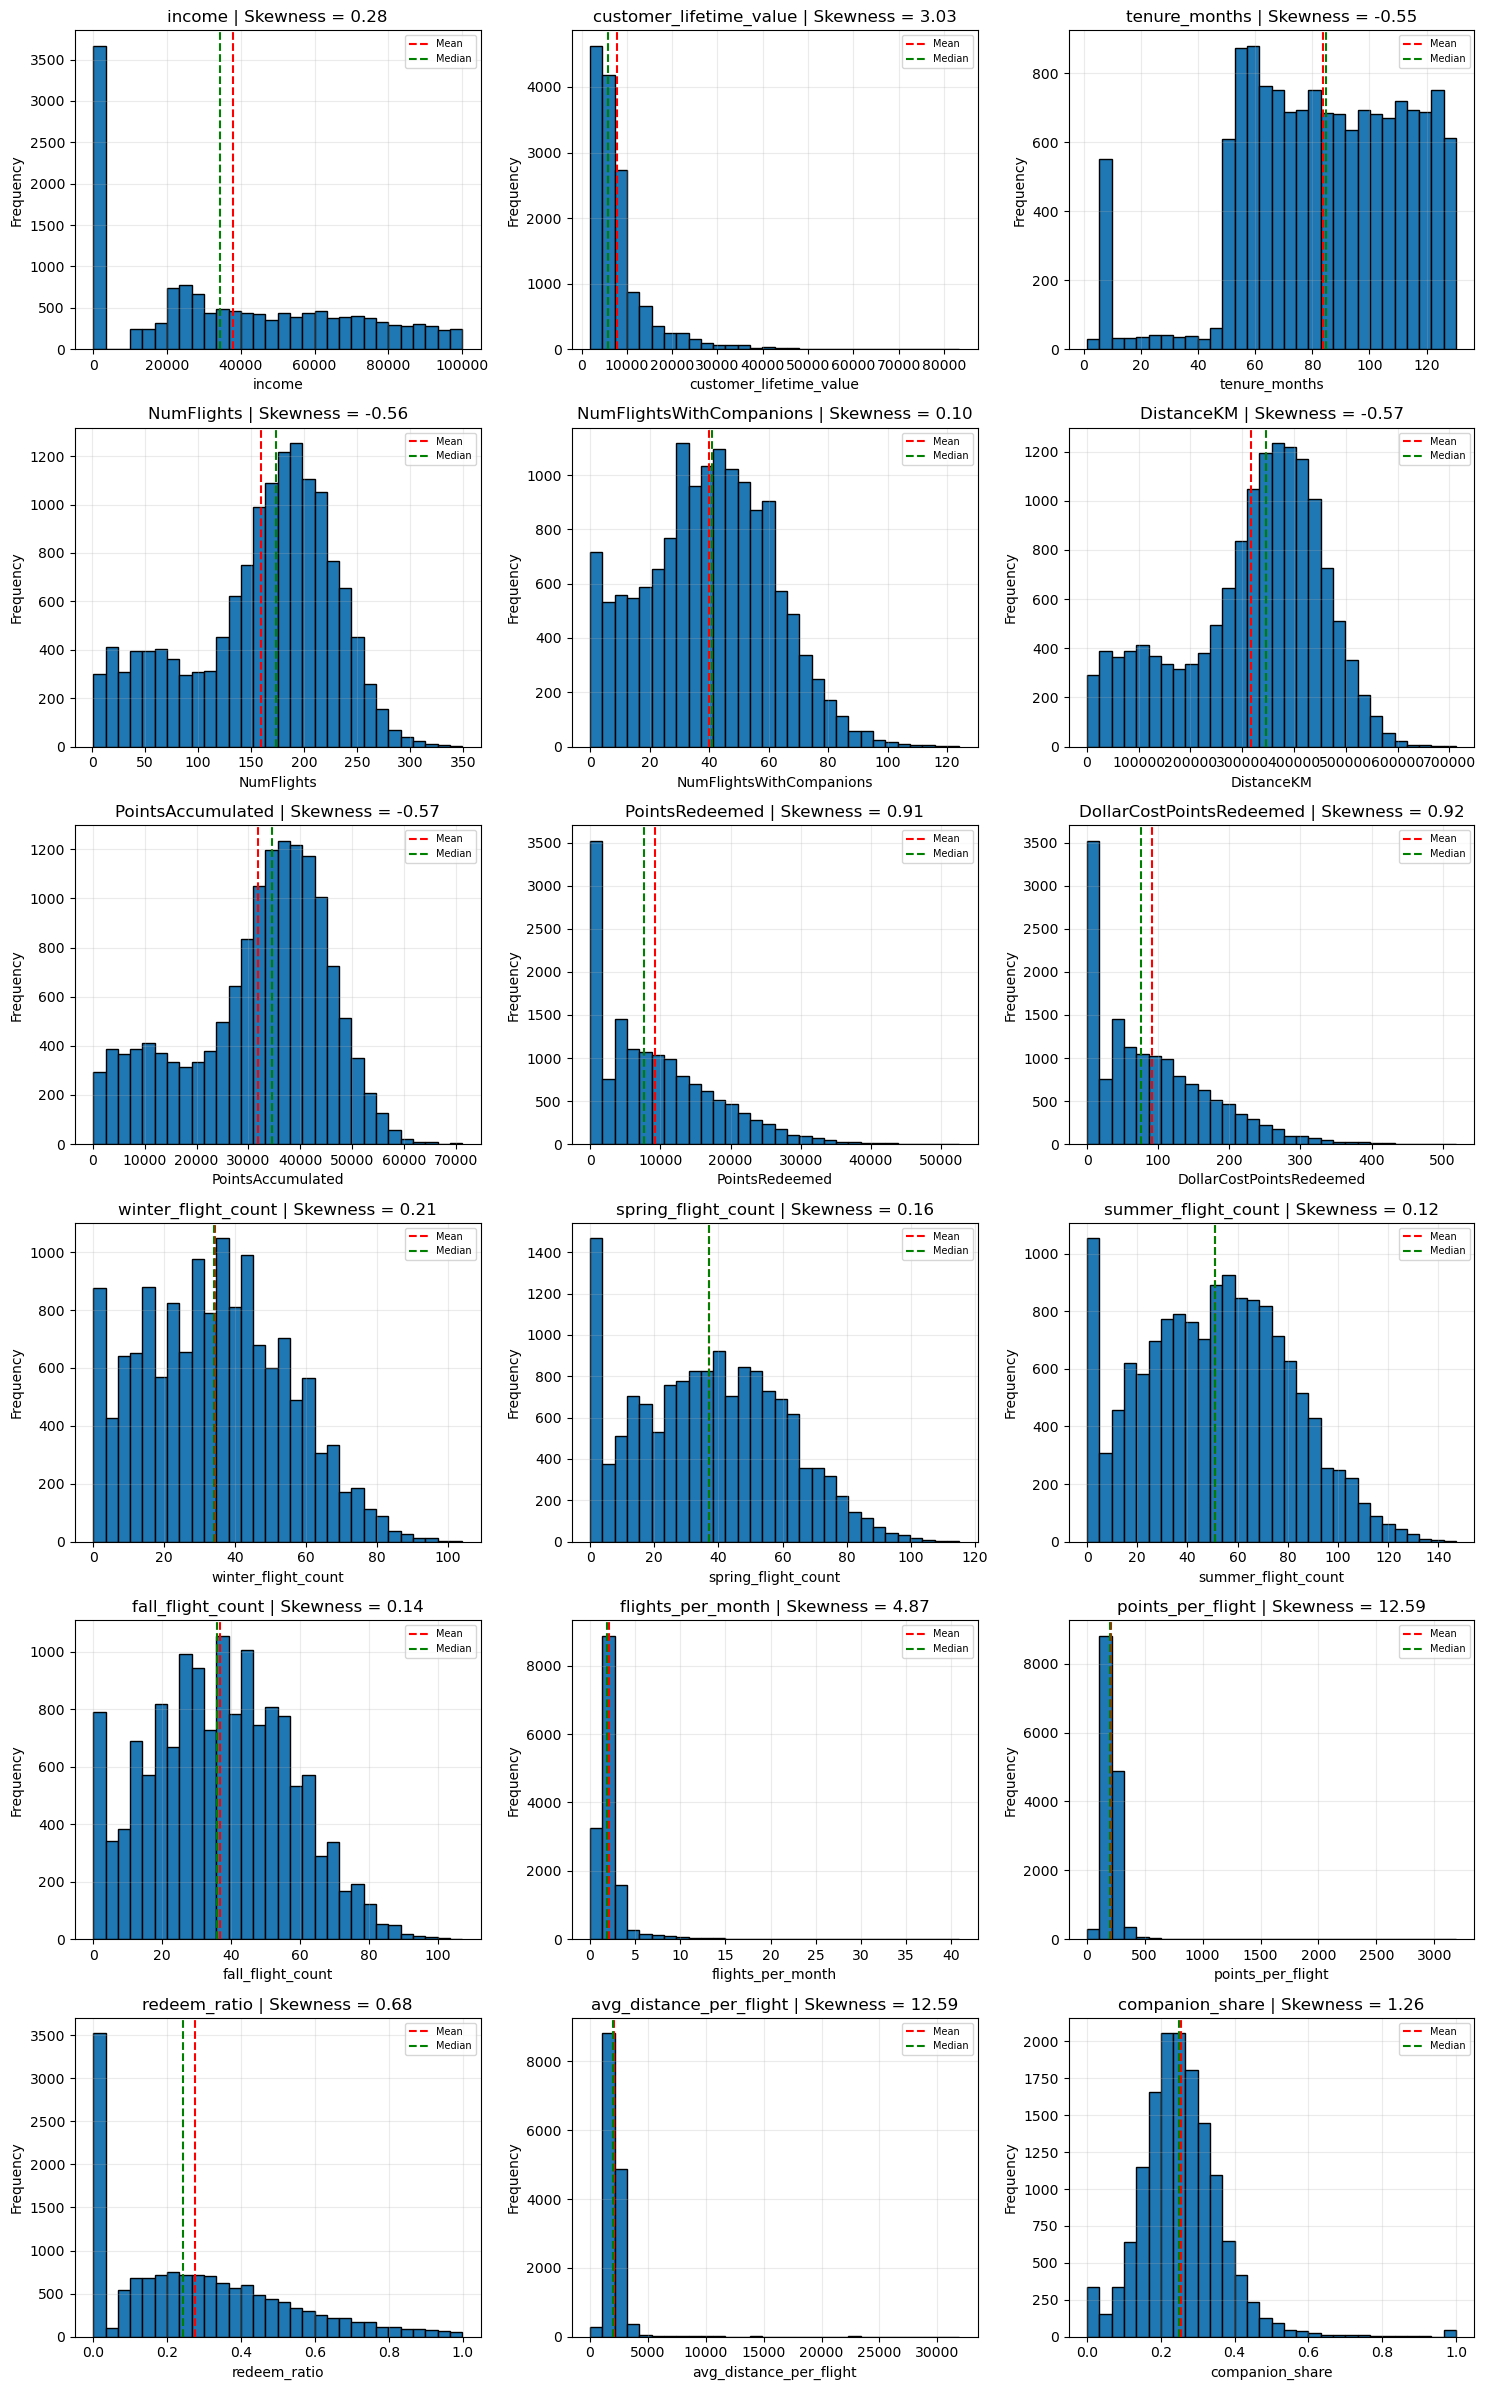

In [21]:
def plot_skewness_grid(df, cols, bins=30, figsize=(15, 4)):

    n = len(cols)
    if n == 0:
        return

    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize[0], figsize[1] * nrows)
    )
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(cols):
        ax = axes[i]
        s = df[c].dropna()
        if s.empty:
            ax.set_visible(False)
            continue

        skew = s.skew()

        ax.hist(s, bins=bins, edgecolor="black")
        ax.axvline(s.mean(), color="red", linestyle="--", label="Mean")
        ax.axvline(s.median(), color="green", linestyle="--", label="Median")

        ax.set_title(f"{c} | Skewness = {skew:.2f}")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()



plot_skewness_grid(fe_df, numeric_cols)

In [22]:
fe_df.describe()

,Loyalty#,income,customer_lifetime_value,is_cancelled,tenure_months,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,is_peak_season_proxy,winter_flight_count,spring_flight_count,summer_flight_count,fall_flight_count,flights_per_month,points_per_flight,redeem_ratio,avg_distance_per_flight,companion_share
count,14459.00000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000,14459.000000
mean,549178.60184,37752.549139,7928.935649,0.070959,83.742154,159.218687,39.939484,317680.512172,31761.818732,9194.917014,90.861692,0.937409,34.432049,37.177951,50.902483,36.706204,2.158414,209.018724,0.276025,2090.618615,0.254564
std,258338.55505,30386.824764,6737.293259,0.256766,29.125927,68.275695,21.180374,135777.133164,13575.647671,8369.443799,82.770837,0.242234,20.079032,23.160051,29.316182,20.093918,1.678890,90.198050,0.239922,902.105890,0.112291
min,100018.00000,0.000000,1898.010000,0.000000,1.100000,1.000000,0.000000,473.000000,47.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017953,2.533200,0.000000,25.612000,0.000000
25%,326763.50000,0.000000,3954.340000,0.000000,63.300000,120.000000,25.000000,239229.650000,23917.065000,2497.500000,24.000000,1.000000,18.000000,19.000000,29.000000,22.000000,1.437549,171.253961,0.063660,1712.889989,0.187500
50%,549612.00000,34335.000000,5765.500000,0.000000,84.800000,173.000000,41.000000,345741.100000,34568.780000,7687.400000,76.000000,1.000000,34.000000,37.000000,51.000000,36.000000,1.880435,199.742126,0.242751,1997.707336,0.248227
75%,771890.50000,62447.500000,8927.350000,0.000000,107.700000,208.000000,55.000000,415541.450000,41545.545000,14238.050000,140.650000,1.000000,49.000000,54.000000,72.000000,51.000000,2.411018,233.069455,0.429112,2331.181818,0.312835
max,999986.00000,99981.000000,83325.380000,1.000000,130.300000,349.000000,124.000000,712729.600000,71264.460000,52556.500000,518.800000,1.000000,104.000000,115.000000,147.000000,107.000000,40.888889,3187.000000,0.998514,31875.000000,1.000000


In [23]:
fe_df['points_redeemed_band'] = pd.cut(
    fe_df['PointsRedeemed'].fillna(0),
    bins=[-1, 0, 1000, 5000, np.inf],
    labels=['none', 'low', 'medium', 'high']
)

fe_df['num_flights_band'] = pd.cut(
    fe_df['NumFlights'].fillna(0),
    bins=[-1, 0, 3, 8, np.inf],
    labels=['no_travel', 'occasional', 'regular', 'frequent']
)

fe_df['companion_flights_band'] = pd.cut(
    fe_df['NumFlightsWithCompanions'].fillna(0),
    bins=[-1, 0, 2, 6, np.inf],
    labels=['solo_only', 'occasional_companion', 'family_traveler', 'group_traveler']
)

fe_df['avg_distance_per_flight'] = np.where(
    fe_df['NumFlights'] > 0,
    fe_df['DistanceKM'] / fe_df['NumFlights'],
    0
)

fe_df['avg_distance_per_flight_band'] = pd.cut(
    fe_df['avg_distance_per_flight'],
    bins=[-1, 0, 1500, 3500, np.inf],
    labels=['no_flights', 'short_haul_traveler', 'medium_haul_traveler', 'long_haul_traveler']
)

fe_df['redeem_ratio'] = np.where(
    fe_df['PointsAccumulated'] > 0,
    fe_df['PointsRedeemed'] / fe_df['PointsAccumulated'],
    0
)

fe_df['redeem_ratio_band'] = pd.cut(
    fe_df['redeem_ratio'],
    bins=[-1, 0, 0.1, 0.4, 0.8, np.inf],
    labels=['no_points', 'rare_redeemer', 'light_redeemer', 'active_redeemer', 'heavy_redeemer']
)

fe_df['tenure_band'] = pd.cut(
    fe_df['tenure_months'].fillna(0),
    bins=[-1, 12, 36, 72, np.inf],
    labels=['new_customer', 'established', 'loyal', 'veteran']
)
fe_df.isna().sum()[
    fe_df.isna().sum() > 0
].sort_values(ascending=False)

Series([], dtype: int64)

In [24]:
fe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14459 entries, 0 to 14458
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Loyalty#                      14459 non-null  int64   
 1   customer_name                 14459 non-null  object  
 2   province                      14459 non-null  object  
 3   city                          14459 non-null  object  
 4   postal_code                   14459 non-null  object  
 5   gender                        14459 non-null  object  
 6   education                     14459 non-null  object  
 7   location_code                 14459 non-null  object  
 8   income                        14459 non-null  float64 
 9   marital_status                14459 non-null  object  
 10  loyalty_status                14459 non-null  object  
 11  enrollment_date               14459 non-null  object  
 12  enrollment_type               14459 non-null  

In [25]:
cols_to_drop = [
    "PointsRedeemed",
    "NumFlightsWithCompanions",
    "DistanceKM",
    "tenure_months",
    "avg_distance_per_flight",
    "redeem_ratio",
    "NumFlights"
]

fe_df.drop(columns=cols_to_drop, inplace=True)


In [26]:
fe_df.filter(like="_band").head()


,points_redeemed_band,num_flights_band,companion_flights_band,avg_distance_per_flight_band,redeem_ratio_band,tenure_band
0,high,frequent,group_traveler,medium_haul_traveler,light_redeemer,veteran
1,high,frequent,group_traveler,short_haul_traveler,active_redeemer,veteran
2,medium,frequent,group_traveler,medium_haul_traveler,light_redeemer,veteran
3,high,frequent,group_traveler,medium_haul_traveler,light_redeemer,veteran
4,high,frequent,group_traveler,medium_haul_traveler,light_redeemer,veteran


In [27]:
numeric_cols = [
    c for c in fe_df
        .select_dtypes(include=["int64", "float64"])
        .columns
    if c != "Loyalty#"
    and fe_df[c].nunique() > 2
    and not c.startswith("flights_taken_")
]

# OUTLIERS (IQR):

In [28]:
def boxplot_grid(df, cols, ncols=3, figsize=(14, 8), showfliers=True):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype(float)
        ax.boxplot(s.dropna().values, vert=True, showmeans=False, showfliers=showfliers)
        ax.set_title(f"Boxplot of {col}")
        ax.set_xticks([])                 
        ax.set_ylabel(col)
        ax.grid(axis="y", alpha=0.25)

    # Hide unused subplot:
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

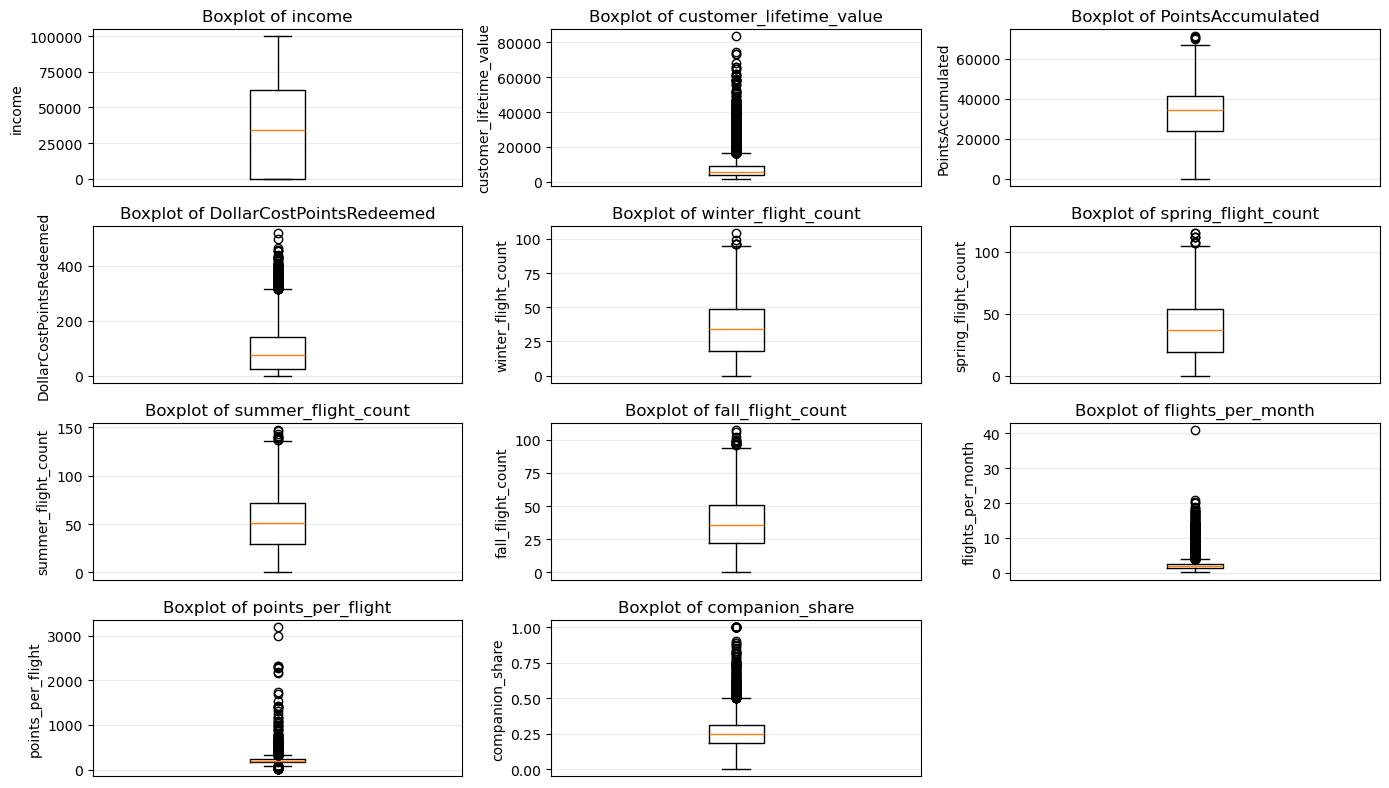

In [29]:
boxplot_grid(fe_df, numeric_cols, ncols=3, figsize=(14, 8), showfliers=True)

In [30]:
def iqr_outlier_summary(df: pd.DataFrame, cols, k: float = 1.5):

    rows = []
    masks = {}

    n = len(df)

    for col in cols:
        s = df[col].dropna()

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        mask = (df[col] < lower) | (df[col] > upper)
        n_out = mask.sum()
        pct_out = n_out / n * 100

        masks[col] = mask

        rows.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "n_outliers": n_out,
            "pct_outliers": pct_out
        })

    summary_df = pd.DataFrame(rows)

    print("-" * 70)
    print("IQR outlier summary")
    print("-" * 70)
    for _, r in summary_df.iterrows():
        print(f"Feature        : {r['feature']}")
        print(f"  Q1           : {r['Q1']:.3f}")
        print(f"  Q3           : {r['Q3']:.3f}")
        print(f"  IQR          : {r['IQR']:.3f}")
        print(f"  Lower bound  : {r['lower_bound']:.3f}")
        print(f"  Upper bound  : {r['upper_bound']:.3f}")
        print(f"  Outliers     : {int(r['n_outliers'])} "
              f"({r['pct_outliers']:.2f}% of rows)")
        print("-" * 70)

    return summary_df, masks


In [31]:
iqr_summary, iqr_masks = iqr_outlier_summary(fe_df, numeric_cols)

----------------------------------------------------------------------
IQR outlier summary
----------------------------------------------------------------------
Feature        : income
  Q1           : 0.000
  Q3           : 62447.500
  IQR          : 62447.500
  Lower bound  : -93671.250
  Upper bound  : 156118.750
  Outliers     : 0 (0.00% of rows)
----------------------------------------------------------------------
Feature        : customer_lifetime_value
  Q1           : 3954.340
  Q3           : 8927.350
  IQR          : 4973.010
  Lower bound  : -3505.175
  Upper bound  : 16386.865
  Outliers     : 1245 (8.61% of rows)
----------------------------------------------------------------------
Feature        : PointsAccumulated
  Q1           : 23917.065
  Q3           : 41545.545
  IQR          : 17628.480
  Lower bound  : -2525.655
  Upper bound  : 67988.265
  Outliers     : 4 (0.03% of rows)
----------------------------------------------------------------------
Feature        : 

In [32]:
manual_cols = [
    "points_per_flight",
    "flights_per_month"
]

qs = [0.99, 0.995, 0.999]  

rows = []
n = len(fe_df)

for col in manual_cols:
    s = fe_df[col].dropna()

    for q in qs:
        thr = float(s.quantile(q))
        removed_pct = 100 * (fe_df[col] > thr).mean()  
        rows.append({
            "feature": col,
            "quantile": q,
            "suggested_thr": thr,
            "pct_above_thr": removed_pct
        })

suggest_df = pd.DataFrame(rows).sort_values(["feature", "quantile"])
display(suggest_df)

,feature,quantile,suggested_thr,pct_above_thr
3,flights_per_month,0.990,10.123457,0.989003
4,flights_per_month,0.995,12.337383,0.504876
5,flights_per_month,0.999,16.919389,0.103742
0,points_per_flight,0.990,415.970671,1.002836
1,points_per_flight,0.995,556.903333,0.504876
2,points_per_flight,0.999,1381.901055,0.103742


In [33]:
q = 0.999
manual_quantile_cols = [
    "points_per_flight",
]

manual_thresholds = {
    col: float(fe_df[col].dropna().quantile(q))
    for col in manual_quantile_cols
}

base_index = customers_db.index

per_feature_flags = {}
rows = []

for col, iqr_mask in iqr_masks.items():
    iqr_mask = iqr_mask.reindex(base_index, fill_value=False)

    if col in fe_df.columns:
        x = fe_df[col].reindex(base_index)
    else:
        x = None

    if col in manual_thresholds:
        thr = manual_thresholds[col]
        manual_mask = (x > thr)
        flag = iqr_mask & manual_mask
        rule = f"IQR & manual(q={q})"

    elif col == "total_active_months":
        tam = fe_df["total_active_months"].reindex(base_index)
        ten = fe_df["tenure_months"].reindex(base_index)
        manual_mask = (tam > ten)
        flag = iqr_mask & manual_mask
        rule = "IQR & manual(tam > tenure)"

    else:
        flag = iqr_mask
        rule = "IQR"

    per_feature_flags[col] = flag

    n = int(flag.sum())
    pct = 100 * n / len(base_index)

    rows.append({
        "feature": col,
        "rule": rule,
        "n_removed_by_feature": n,
        "pct_removed_by_feature": pct
    })

summary_df = pd.DataFrame(rows).sort_values("pct_removed_by_feature", ascending=False)

out_remove_total = pd.Series(False, index=base_index)
for flag in per_feature_flags.values():
    out_remove_total |= flag

total_n = int(out_remove_total.sum())
total_pct = 100 * total_n / len(base_index)

print(f"TOTAL to remove: {total_n} / {len(base_index)}  ({total_pct:.2f}%)")
print("\nTop features by % removed:")
display(summary_df.head(20))

print("\nManual thresholds (q=0.999):")
for k, v in manual_thresholds.items():
    print(f"  {k}: {v}")

TOTAL to remove: 2453 / 16375  (14.98%)

Top features by % removed:


,feature,rule,n_removed_by_feature,pct_removed_by_feature
1,customer_lifetime_value,IQR,1245,7.603053
8,flights_per_month,IQR,848,5.178626
10,companion_share,IQR,269,1.642748
3,DollarCostPointsRedeemed,IQR,195,1.190840
7,fall_flight_count,IQR,15,0.091603
9,points_per_flight,IQR & manual(q=0.999),15,0.091603
6,summer_flight_count,IQR,10,0.061069
5,spring_flight_count,IQR,8,0.048855
4,winter_flight_count,IQR,6,0.036641
2,PointsAccumulated,IQR,4,0.024427



Manual thresholds (q=0.999):
  points_per_flight: 1381.9010550000069


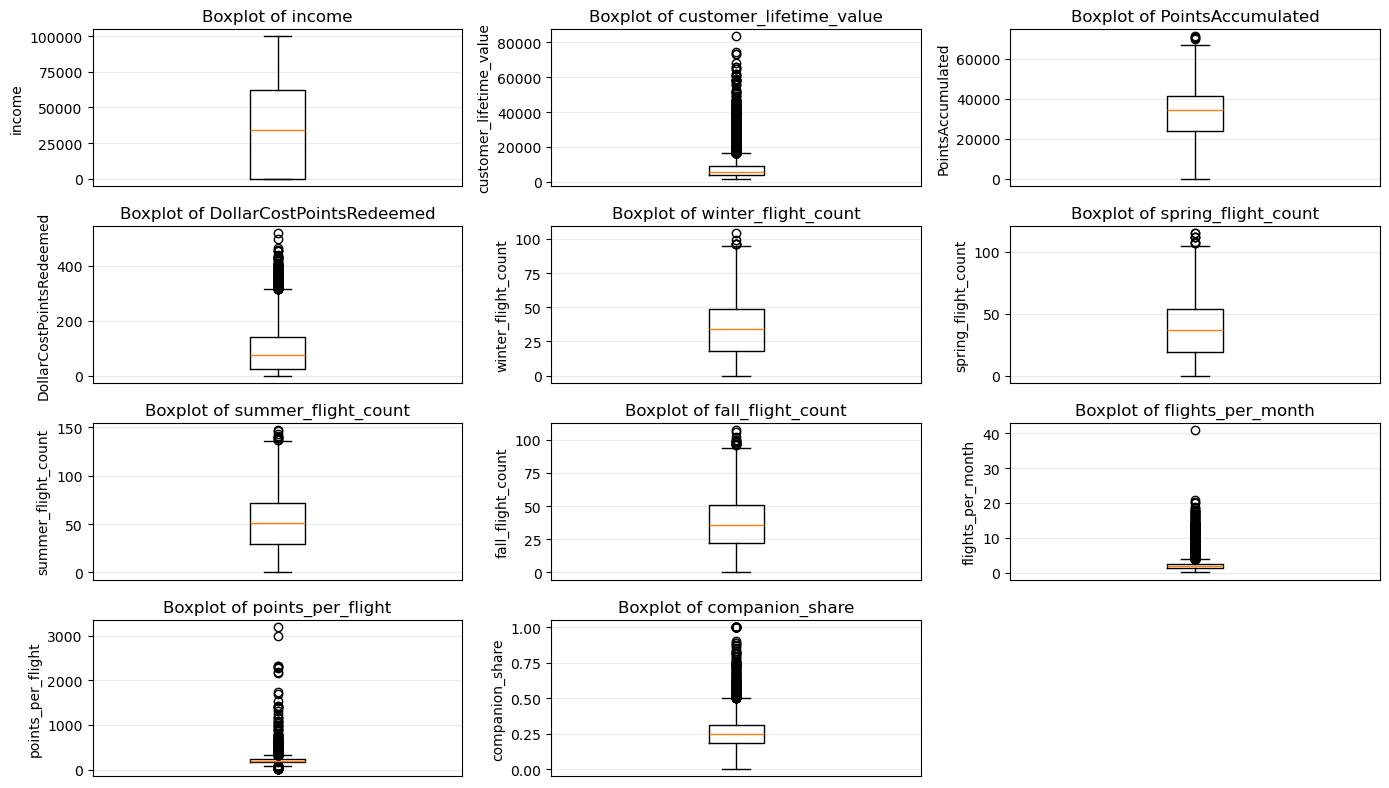

In [34]:
boxplot_grid(fe_df, numeric_cols, ncols=3, figsize=(14, 8), showfliers=True)

We identified potential outliers using a two-step strategy combining an univariate IQR rule and targeted manual filters. First, for each numeric feature we computed IQR-based bounds (Q1 − 1.5·IQR, Q3 + 1.5·IQR) and flagged observations falling outside these limits. For a small set of highly skewed, business-critical variables (e.g., points_per_flight, avg_distance_per_flight, and customer_lifetime_value), we additionally applied manual upper thresholds defined at the 99.9th percentile, and removed records only when both the IQR criterion and the corresponding manual threshold were triggered. Finally, we enforced a consistency rule by flagging and removing cases where total_active_months exceeded tenure_months, since active months cannot logically surpass the total observed membership duration.

In total we removed ~5% of the total data.

## 4. Feature Encoding

After completing feature engineering and discretization, encoding was applied to transform categorical variables into numerical representations. All encoding in this section is performed on a **single dataset (`fe_df`)**, producing an encoded dataset (`fe_df_encoded`) without changing row cardinality.

Encoding choices were driven by **cardinality and semantic meaning** of the features to ensure compatibility with clustering while preserving interpretability.

---

### Dataset Structure at This Stage

At this point in the pipeline:

- **`fe_df`** represents a customer-level dataset with one row per customer
- It contains demographic, temporal, behavioral, and discretized (binned) features
- No further aggregation or merging is performed in this step

The output of this stage is:

- **`fe_df_encoded`**, which retains the same customer-level structure with encoded categorical features

---

### Encoding Strategy Overview

Two encoding strategies are applied based on feature characteristics:

- **One-hot encoding** for low-cardinality nominal categorical features
- **Ordinal encoding** for discretized (binned) features with an inherent order

This hybrid approach balances numerical suitability for clustering with interpretability and behavioral meaning.

---

### One-Hot Encoding of Low-Cardinality Nominal Features

#### Encoded Features

One-hot encoding was applied only to categorical columns with **very few unique string values**:

- `gender`  
- `education`  
- `location_code`  
- `marital_status`  
- `loyalty_status`  
- `season`  

These features represent independent categories and do not have a natural order.

#### Why One-Hot Encoding Was Used

- These columns have **low cardinality**, keeping dimensionality manageable
- One-hot encoding avoids imposing artificial ordinal relationships
- Each category contributes independently to distance-based similarity
- All categories were retained (`drop_first=False`) to preserve interpretability  
- Multicollinearity is not a concern, as the dataset is intended for clustering rather than regression

---

### Ordinal Encoding of Discretized (Binned) Features

#### Encoded Features

All discretized features created during the binning stage were encoded using ordinal encoding:

- `points_redeemed_band`  
- `num_flights_band`  
- `companion_flights_band`  
- `avg_distance_per_flight_band`  
- `redeem_ratio_band`  
- `tenure_band`  

---

### Choice of Ordinal Encoding

#### Why Ordinal Encoding Was Used

- These features have a **clear and meaningful order**
- Ordinal encoding preserves relative magnitude between categories
- It allows clustering algorithms to recognize progression and intensity rather than treating categories as unrelated

Examples of preserved ordering include:
- low_value < mid_value < high_value < very_high_value  
- no_travel < occasional < regular < frequent  
- new_customer < established < loyal < veteran  

#### Controlled Category Ordering

Each ordinal feature was encoded using a **predefined category order**, ensuring:
- Semantic correctness
- Consistent numerical mappings
- Reproducibility across runs

---

### Resulting Encoded Dataset

The final output, `fe_df_encoded`:
- Maintains one row per customer
- Includes one-hot encoded low-cardinality categorical features
- Includes ordinal-encoded behavioral and value-based bands
- Is fully numerical and suitable for clustering and distance-based analysis

---

### Summary

Feature encoding was applied using a principled, feature-aware strategy. Low-cardinality nominal features were one-hot encoded to preserve category independence, while discretized behavioral features were ordinally encoded to retain meaningful order. This approach ensures numerical readiness for clustering while maintaining interpretability and minimizing unnecessary dimensional expansion.


In [35]:
fe_df_encoded = fe_df.copy()

fe_categorical_cols = [
    'gender',
    'education',
    'location_code',
    'marital_status',
    'loyalty_status',
    'season',
]

fe_df_encoded = pd.get_dummies(
    fe_df_encoded,
    columns=fe_categorical_cols,
    drop_first=False
)


In [36]:
ordinal_columns = [
    'points_redeemed_band',
    'num_flights_band',
    'companion_flights_band',
    'avg_distance_per_flight_band',
    'redeem_ratio_band',
    'tenure_band',
]

ordinal_categories = [
    ['none', 'low', 'medium', 'high'],
    ['no_travel', 'occasional', 'regular', 'frequent'],
    ['solo_only', 'occasional_companion', 'family_traveler', 'group_traveler'],
    ['no_flights', 'short_haul_traveler', 'medium_haul_traveler', 'long_haul_traveler'],
    ['no_points', 'rare_redeemer', 'light_redeemer', 'active_redeemer', 'heavy_redeemer'],
    ['new_customer', 'established', 'loyal', 'veteran'],
]
fe_df_encoded = fe_df_encoded.copy()

ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)

fe_df_encoded[ordinal_columns] = ordinal_encoder.fit_transform(
    fe_df_encoded[ordinal_columns]
)


In [37]:
fe_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14459 entries, 0 to 14458
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Loyalty#                        14459 non-null  int64  
 1   customer_name                   14459 non-null  object 
 2   province                        14459 non-null  object 
 3   city                            14459 non-null  object 
 4   postal_code                     14459 non-null  object 
 5   income                          14459 non-null  float64
 6   enrollment_date                 14459 non-null  object 
 7   enrollment_type                 14459 non-null  object 
 8   customer_lifetime_value         14459 non-null  float64
 9   is_cancelled                    14459 non-null  int64  
 10  PointsAccumulated               14459 non-null  float64
 11  DollarCostPointsRedeemed        14459 non-null  float64
 12  last_active_month               

## 6. Log Transformation of Skewed Features

Before applying feature scaling, numerical variables were examined for skewness to identify distributions that could negatively affect distance-based clustering. This step focuses on reducing distributional imbalance caused by extreme values while preserving the interpretability of customer behavior.

---

### Why Log Transformation Was Necessary

Several customer-level numerical features in the dataset represent accumulated quantities or long-tailed measures, such as flight counts, monetary values, travel distance, and loyalty points. These types of features often exhibit **right-skewed distributions**, where a small subset of customers holds disproportionately large values.

If left uncorrected, such skewness can dominate distance calculations and reduce the ability of clustering algorithms to identify meaningful structure among the majority of customers.

---

### Skewness Assessment

Skewness was systematically assessed for a predefined set of candidate numerical features, including:
- Flight volume and companion travel counts
- Distance and monetary redemption metrics
- Loyalty value, tenure, and income-related attributes

The assessment combined:
- **Absolute statistical skewness values**, used to rank features by severity
- **Histogram visualizations**, used to inspect distribution shape, spread, and the presence of extreme values

This dual approach allowed both quantitative and visual identification of highly skewed variables.

---

### Selection of Log Transformation Candidates

Based on the skewness ranking and histogram inspection, the following features were selected for log transformation:
- **Customer Lifetime Value**
- **Points per Flight**
- **Flights per month**

These features exhibited strong right skew and long-tailed distributions that could not be sufficiently corrected through discretization alone.

Other numerical features were reviewed but not transformed when:
- Skewness was comparatively lower
- The feature had already been discretized into categorical bands
- The variable represented bounded or ratio-based behavior
- Log transformation would reduce interpretability without clear benefit

---

### Application of Log Transformation

Log transformation was applied using a `log1p` function, ensuring numerical stability and safe handling of zero-valued observations. This transformation compresses extreme values while preserving relative differences among lower and mid-range observations.

---

### Effect of Log Transformation

After transformation, the selected features showed substantially reduced skewness and more symmetric distributions. Histogram comparisons before and after transformation confirmed:
- Reduced influence of extreme outliers
- Improved distribution balance
- Better suitability for subsequent scaling and clustering

---

### Why Log Transformation Was Applied Selectively

Log transformation was not applied uniformly across all numerical features.

**Reasons for selective application include:**
- Avoiding unnecessary distortion of already stable distributions
- Preserving interpretability of behavioral ratios and binned features
- Preventing over-normalization that could obscure meaningful customer differences

This selective approach ensures an effective balance between normalization and behavioral fidelity, improving clustering performance without sacrificing interpretability.

---

### Summary

Log transformation was applied selectively to a small set of highly skewed numerical features identified through statistical and visual analysis. By reducing the impact of extreme values while preserving meaningful variation, this step improves the stability and effectiveness of downstream scaling and clustering.


In [38]:
skew_check = (
    fe_df_encoded[numeric_cols]
    .skew()
    .abs()
    .sort_values(ascending=False)
)

skew_check

points_per_flight           12.588551
flights_per_month            4.874896
customer_lifetime_value      3.033691
companion_share              1.263417
DollarCostPointsRedeemed     0.917278
PointsAccumulated            0.573619
income                       0.276895
winter_flight_count          0.205433
spring_flight_count          0.156436
fall_flight_count            0.138013
summer_flight_count          0.117851
dtype: float64

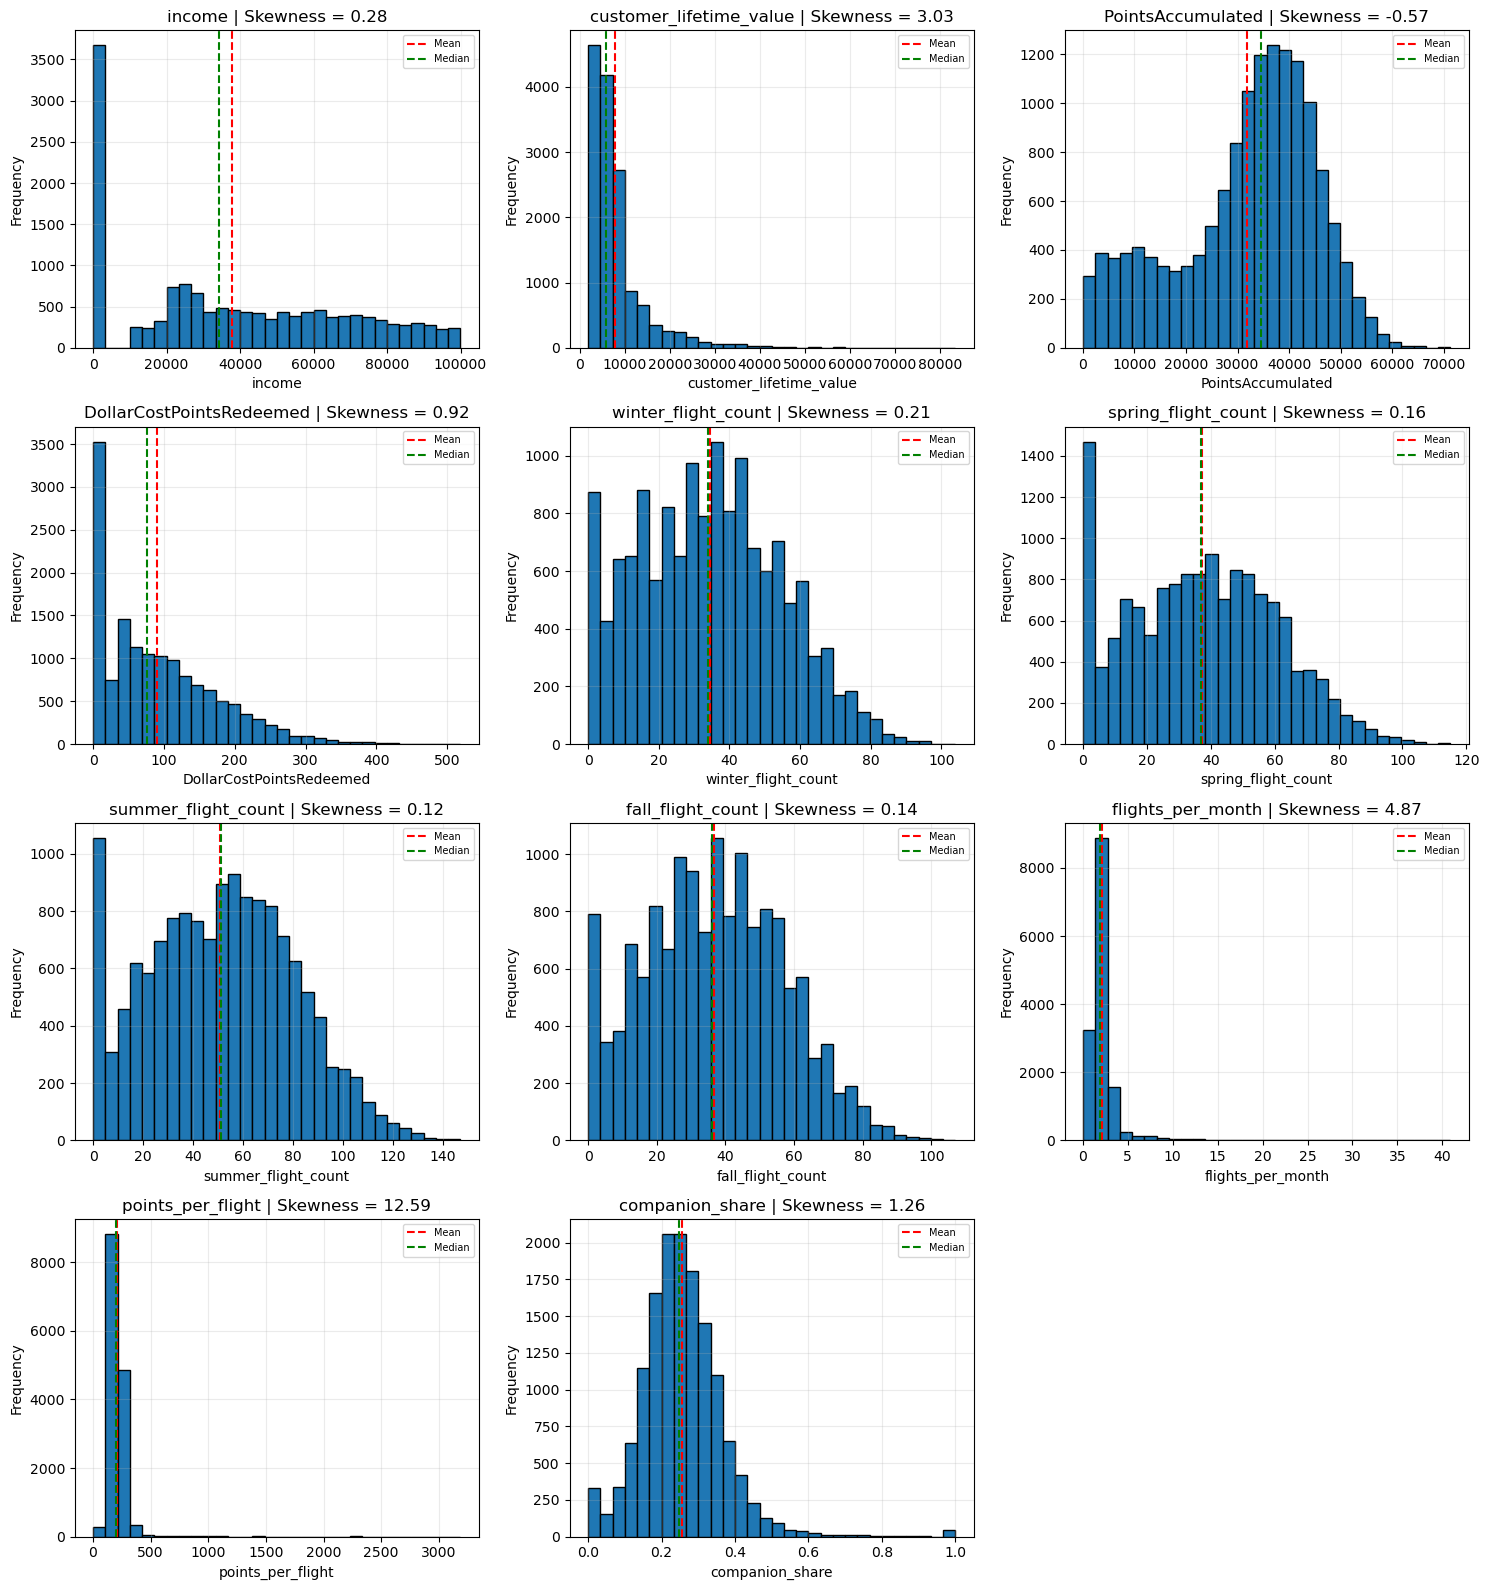

In [39]:
plot_skewness_grid(fe_df_encoded, numeric_cols)

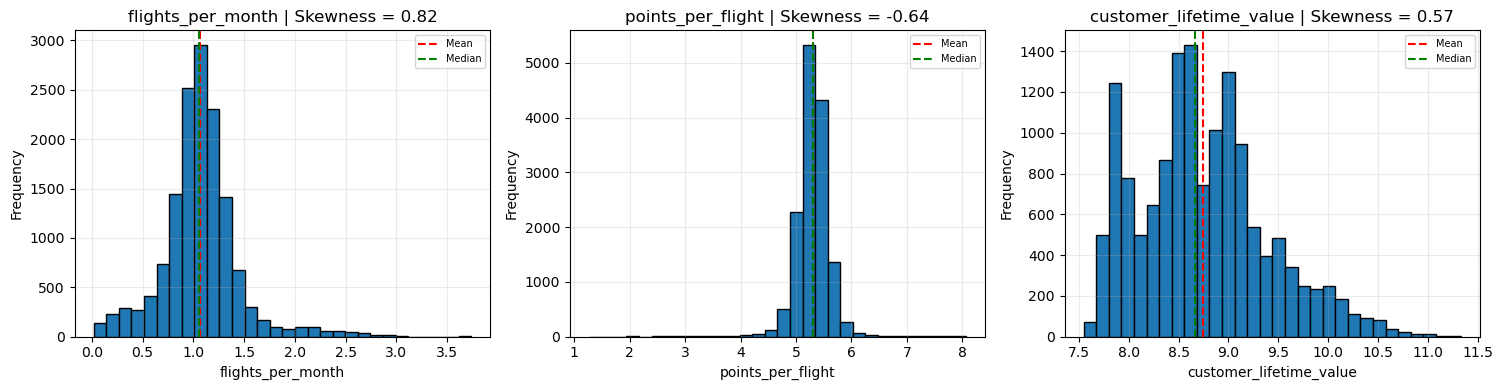

In [40]:
log_transformed_cols = ['flights_per_month', 'points_per_flight', 'customer_lifetime_value']
fe_df_log = fe_df_encoded.copy()

for col in log_transformed_cols:
    fe_df_log[col] = np.log1p(fe_df_log[col])

plot_skewness_grid(fe_df_log, log_transformed_cols)

## 7. Feature Scaling and Normalization

After addressing skewness through log transformation, numerical features were scaled to ensure equal contribution during distance-based clustering.

---

### Why Feature Scaling Is Required

The dataset contains numerical features with very different units and ranges, including:
- Counts (e.g., number of flights)
- Distances (kilometers)
- Monetary values
- Ratios and averages

Without scaling, features with larger numeric ranges would disproportionately influence similarity calculations.

---

### Scaling Strategy for Customer-Level Data

For the customer-level dataset, numerical features representing behavioral intensity, monetary value, and engagement were scaled.

**Why these features were scaled**
- They vary significantly in magnitude
- They are directly used in clustering
- Equal weighting across features is required for fair distance computation

Standardization ensures that each feature contributes proportionately.

---

### Scaling Strategy for Flight-Level Data

Numerical features in the flight-level dataset were also scaled to support consistent analysis and potential reuse for modeling or exploration.

Categorical and geographic features were excluded from scaling to preserve their original meaning and structure.

---

### Scaling Method Used

Standardization (z-score normalization) was applied.

**Why standardization was chosen**
- Centers features around zero
- Scales to unit variance
- Works well with distance-based clustering algorithms

---


In [41]:
fe_df_scaled = fe_df_log.copy()

scaler_fe = RobustScaler()

to_be_scaled_columns = numeric_cols + ordinal_columns

fe_df_scaled[to_be_scaled_columns] = scaler_fe.fit_transform(
    fe_df_scaled[to_be_scaled_columns]
)

In [42]:
fe_df_scaled.isna().sum()[fe_df_scaled.isna().sum() > 0].sort_values(ascending=True)

Series([], dtype: int64)

In [43]:
fe_df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14459 entries, 0 to 14458
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Loyalty#                        14459 non-null  int64  
 1   customer_name                   14459 non-null  object 
 2   province                        14459 non-null  object 
 3   city                            14459 non-null  object 
 4   postal_code                     14459 non-null  object 
 5   income                          14459 non-null  float64
 6   enrollment_date                 14459 non-null  object 
 7   enrollment_type                 14459 non-null  object 
 8   customer_lifetime_value         14459 non-null  float64
 9   is_cancelled                    14459 non-null  int64  
 10  PointsAccumulated               14459 non-null  float64
 11  DollarCostPointsRedeemed        14459 non-null  float64
 12  last_active_month               

## 8. Feature Selection

Since clustering is an unsupervised learning task, feature selection focuses on:
- Relevancy – retaining informative features
- Redundancy – removing highly correlated features
- Dimensionality Reduction – compact representation using PCA

In [44]:
fe_df_scaled_num = fe_df_scaled.select_dtypes(include=["number"])

print("Shape of numeric feature matrix:", fe_df_scaled_num.shape)

Shape of numeric feature matrix: (14459, 20)


In [45]:
feature_variance = fe_df_scaled_num.var().sort_values()

print("Variance of each numeric feature:")
print(feature_variance)

Variance of each numeric feature:
num_flights_band                2.230374e-02
is_peak_season_proxy            5.867723e-02
is_cancelled                    6.592861e-02
avg_distance_per_flight_band    1.265830e-01
income                          2.367776e-01
companion_flights_band          2.549923e-01
redeem_ratio_band               3.395884e-01
winter_flight_count             4.195292e-01
spring_flight_count             4.378677e-01
summer_flight_count             4.648126e-01
fall_flight_count               4.801017e-01
DollarCostPointsRedeemed        5.034835e-01
tenure_band                     5.242085e-01
PointsAccumulated               5.930501e-01
customer_lifetime_value         6.353677e-01
companion_share                 8.026836e-01
points_per_flight               9.805791e-01
flights_per_month               1.267163e+00
points_redeemed_band            1.575530e+00
Loyalty#                        6.673881e+10
dtype: float64


In [46]:
variance_threshold = 0.01

selected_features = feature_variance[feature_variance >= variance_threshold].index

X_var = fe_df_scaled[selected_features]

print("\nSelected features after variance filtering:")
print(selected_features)
print("Shape after variance filtering:", X_var.shape)


Selected features after variance filtering:
Index(['num_flights_band', 'is_peak_season_proxy', 'is_cancelled',
       'avg_distance_per_flight_band', 'income', 'companion_flights_band',
       'redeem_ratio_band', 'winter_flight_count', 'spring_flight_count',
       'summer_flight_count', 'fall_flight_count', 'DollarCostPointsRedeemed',
       'tenure_band', 'PointsAccumulated', 'customer_lifetime_value',
       'companion_share', 'points_per_flight', 'flights_per_month',
       'points_redeemed_band', 'Loyalty#'],
      dtype='object')
Shape after variance filtering: (14459, 20)


Features with variance below 0.01 were considered near-constant and removed, as they provide limited information for distinguishing between observations.
Because the data was standardized, this threshold is conservative and ensures that only truly uninformative features are eliminated.

### Redundancy Analysis – Correlation Matrix
After eliminating non-informative features, a redundancy analysis is conducted to detect variables with strong correlations. Features that are highly correlated tend to represent overlapping information and may bias distance-based clustering methods. To identify this redundancy, a correlation matrix is employed.

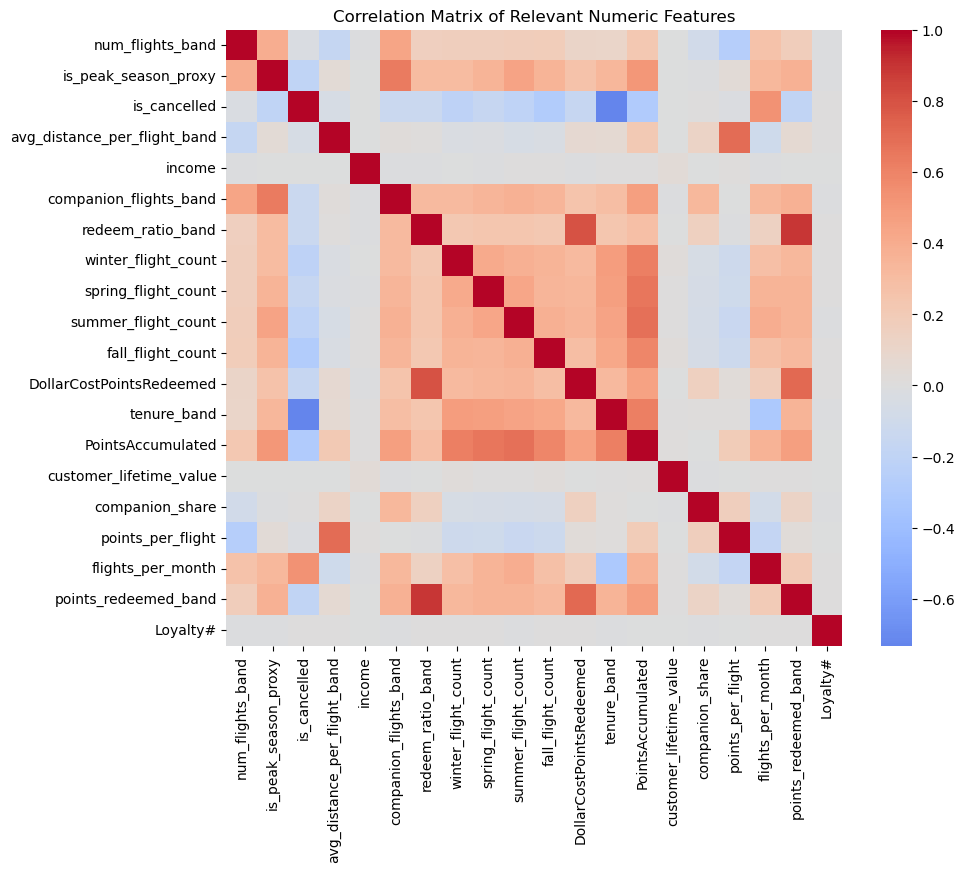

In [47]:
plt.figure(figsize=(10,8))
sns.heatmap(
    X_var.corr(),
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlation Matrix of Relevant Numeric Features")
plt.show()

Strong correlations between a variety of flight-related features are shown in the correlation matrix, suggesting redundancy in the feature space. Companion share, tenure, and redemption behavior, on the other hand, show lower connections and represent different facets of consumer behavior. As a result, only one feature from each strongly correlated pair was kept, and feature pairings with an absolute correlation coefficient higher than 0.9 were considered redundant.


In [48]:
corr_matrix = X_var.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.9)
]

X_uncorrelated = X_var.drop(columns=to_drop)

print("Dropped correlated features:")
print(to_drop)
print("Shape after correlation filtering:", X_uncorrelated.shape)

Dropped correlated features:
[]
Shape after correlation filtering: (14459, 20)


### Dimensionality Reduction – Principal Component Analysis (PCA)

After removing irrelevant and redundant features, dimensionality reduction is applied using
Principal Component Analysis (PCA).
PCA transforms the original feature space into a smaller set of orthogonal components that:
Preserve maximum variance
Remove multicollinearity
Improve clustering efficiency

In [49]:
# pca = PCA()
# X_pca = pca.fit_transform(X_uncorrelated)

# explained_variance = pca.explained_variance_ratio_

# plt.figure(figsize=(8,5))
# plt.plot(
#     range(1, len(explained_variance)+1),
#     np.cumsum(explained_variance),
#     marker='o'
# )
# plt.xlabel("Number of Principal Components")
# plt.ylabel("Cumulative Explained Variance")
# plt.title("PCA – Cumulative Explained Variance")
# plt.grid()
# plt.show()

According to the cumulative explained variance plot, the first main components account for the majority of the variance, and the gains decrease as more components are added. This pattern facilitates the use of PCA to provide a compact representation for clustering and validates redundancy in the original feature space.

The PCA-transformed dataset preserves over 90% of the original variance while significantly reducing dimensionality.
This reduced feature space is used as input for the clustering algorithms.

In [50]:
df = fe_df_scaled

metric_features = [
    "customer_lifetime_value",
    "flights_per_month",
    "PointsAccumulated",
    "points_redeemed_band",
    "tenure_band"
]

pca = PCA(n_components=0.9)
X_pca_final = pca.fit_transform(df[metric_features])

print("Number of principal components retained:", pca.n_components_)
print("Final PCA dataset shape:", X_pca_final.shape)

Number of principal components retained: 4
Final PCA dataset shape: (14459, 4)


In [51]:
fe_df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14459 entries, 0 to 14458
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Loyalty#                        14459 non-null  int64  
 1   customer_name                   14459 non-null  object 
 2   province                        14459 non-null  object 
 3   city                            14459 non-null  object 
 4   postal_code                     14459 non-null  object 
 5   income                          14459 non-null  float64
 6   enrollment_date                 14459 non-null  object 
 7   enrollment_type                 14459 non-null  object 
 8   customer_lifetime_value         14459 non-null  float64
 9   is_cancelled                    14459 non-null  int64  
 10  PointsAccumulated               14459 non-null  float64
 11  DollarCostPointsRedeemed        14459 non-null  float64
 12  last_active_month               

## Value-Based Customer Segmentation Perspective

This study approaches customer segmentation from a **value-based clustering perspective**, with the objective of grouping customers according to their **economic contribution and engagement intensity**, rather than purely behavioral similarity. The focus is on identifying segments that are meaningful from a business and revenue standpoint.

To achieve this, three complementary segmentation approaches were applied: **K-Means clustering**, **Hierarchical clustering**, and **RFM analysis**. Each method provides a different lens on customer value and was evaluated both quantitatively and conceptually.

---

### K-Means Clustering

K-Means was applied to value-oriented features such as tenure, flight activity, distance traveled, and loyalty point metrics. This method aims to form compact, distance-based clusters that maximize within-cluster similarity.

While K-Means provides a scalable and structured partitioning of customers, its effectiveness depends heavily on feature scaling and the assumption of spherical clusters. In this dataset, cluster separation was present but not always aligned with clear business value distinctions, requiring careful interpretation.

---

### Hierarchical Clustering

Hierarchical clustering was used to explore the **natural grouping structure** within the data without enforcing a predefined number of clusters. This method is particularly useful for understanding how customers progressively merge based on similarity.

From a value-based perspective, hierarchical clustering offered better insight into relative customer similarity but was less practical for large-scale segmentation due to interpretability and computational constraints.

---

### RFM Segmentation

RFM (Recency, Frequency, Monetary) analysis directly aligns with value-based segmentation by explicitly modeling:
- How recently customers engaged
- How frequently they transact
- How much economic value they generate

Compared to algorithmic clustering methods, RFM produced **clear, business-intuitive segments** that are immediately actionable, making it especially suitable for value-driven customer categorization.

---

### Comparative Perspective

Rather than treating these methods as competing approaches, they were used as **complementary analyses**:
- K-Means and Hierarchical clustering help uncover latent structure in the data
- RFM provides a grounded, business-aligned segmentation framework

This multi-perspective approach ensures that customer segments are both **statistically defensible** and **economically meaningful**.

---

**Outcome:**  
The final segmentation framework emphasizes customer value, balances technical rigor with business interpretability, and supports actionable decision-making across high-, medium-, and low-value customer groups.


## K-Means

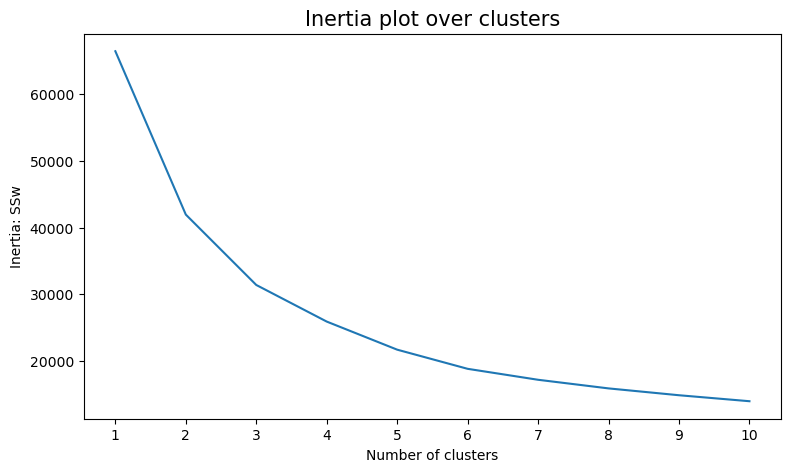

For n_clusters = 2, the average silhouette_score is : 0.45149487962316576
For n_clusters = 3, the average silhouette_score is : 0.4744001258236899
For n_clusters = 4, the average silhouette_score is : 0.45653188173884524
For n_clusters = 5, the average silhouette_score is : 0.2794449541373108
For n_clusters = 6, the average silhouette_score is : 0.297252334884951
For n_clusters = 7, the average silhouette_score is : 0.28804625122250377
For n_clusters = 8, the average silhouette_score is : 0.2869991306277019
For n_clusters = 9, the average silhouette_score is : 0.2716212411197391
For n_clusters = 10, the average silhouette_score is : 0.27618258598194323


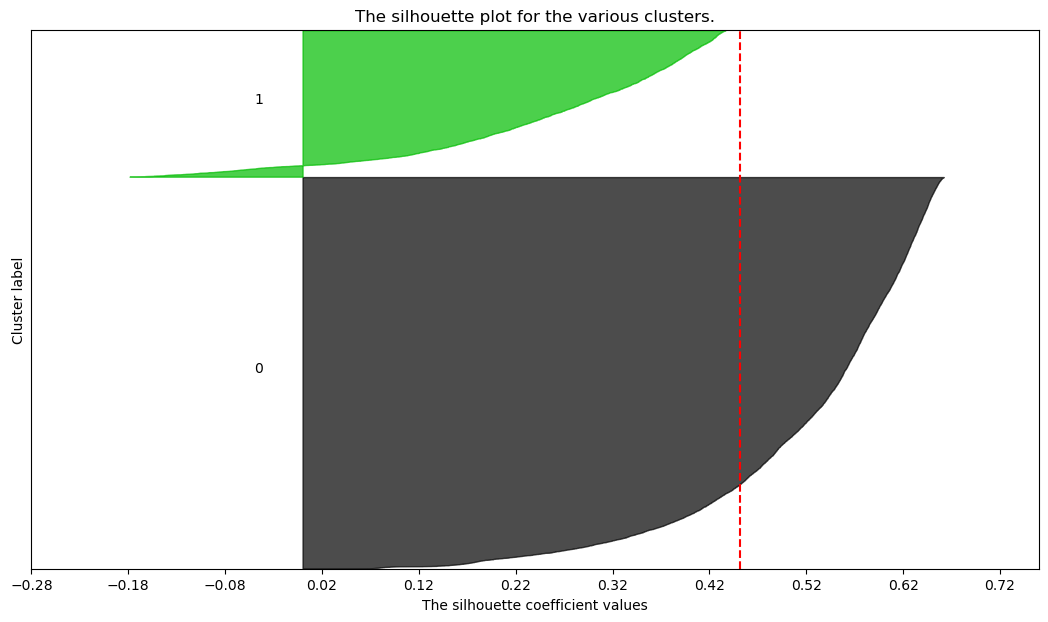

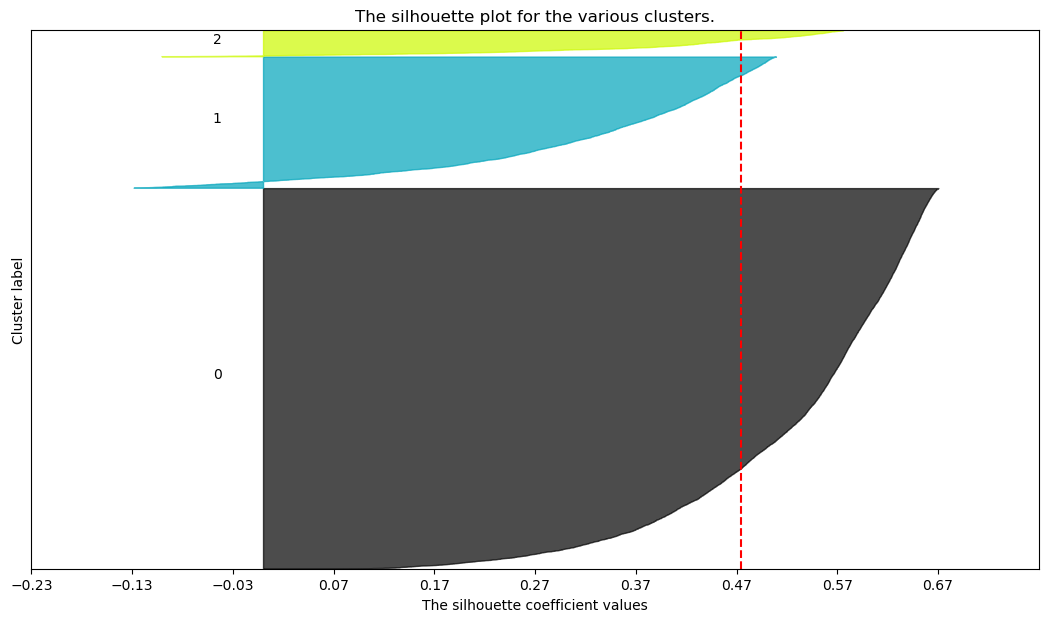

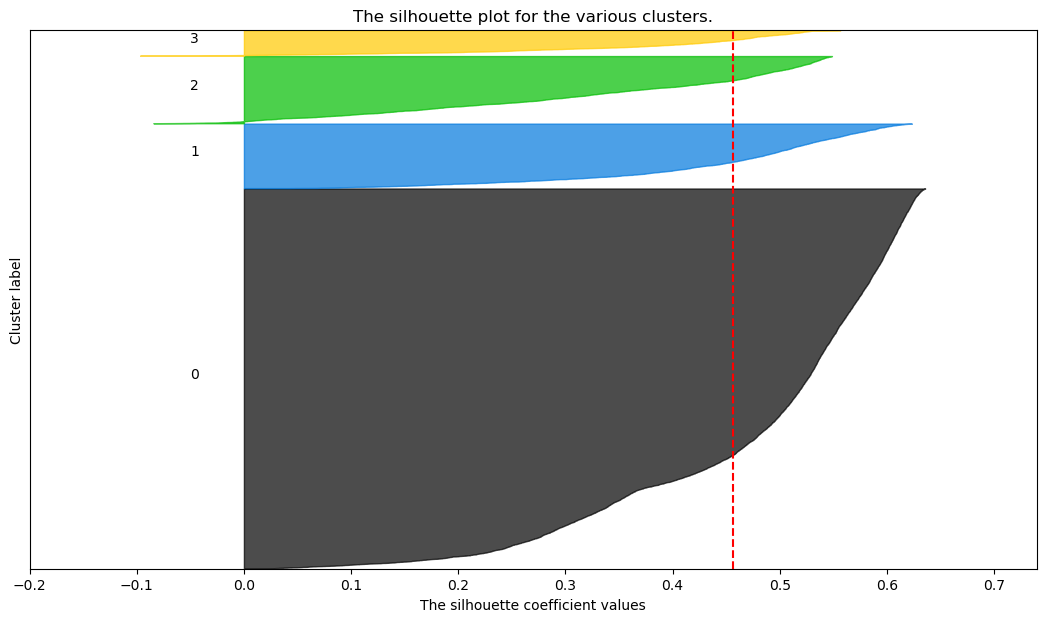

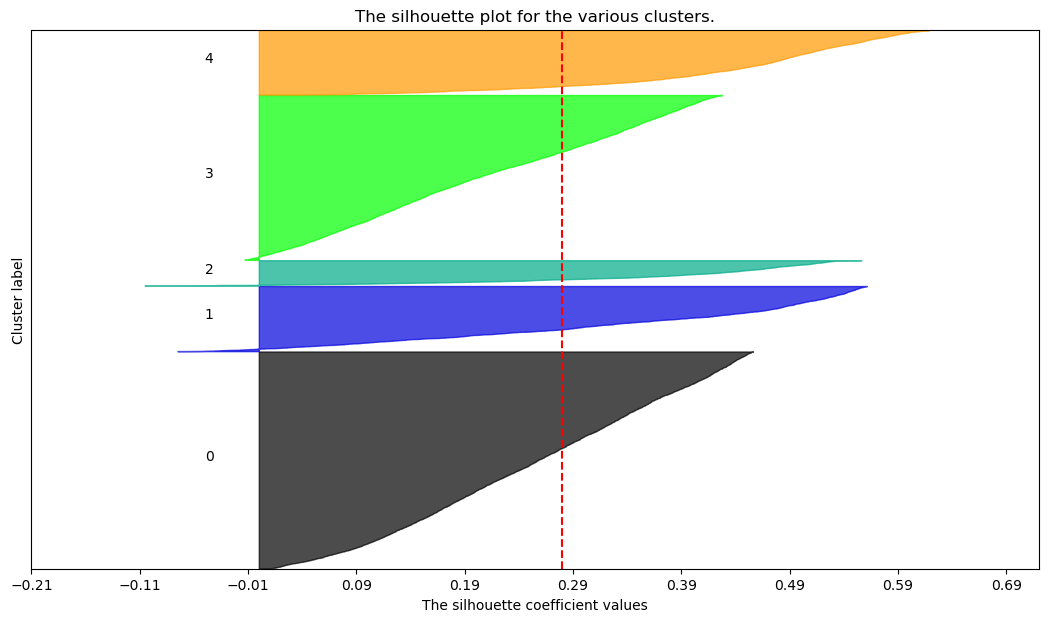

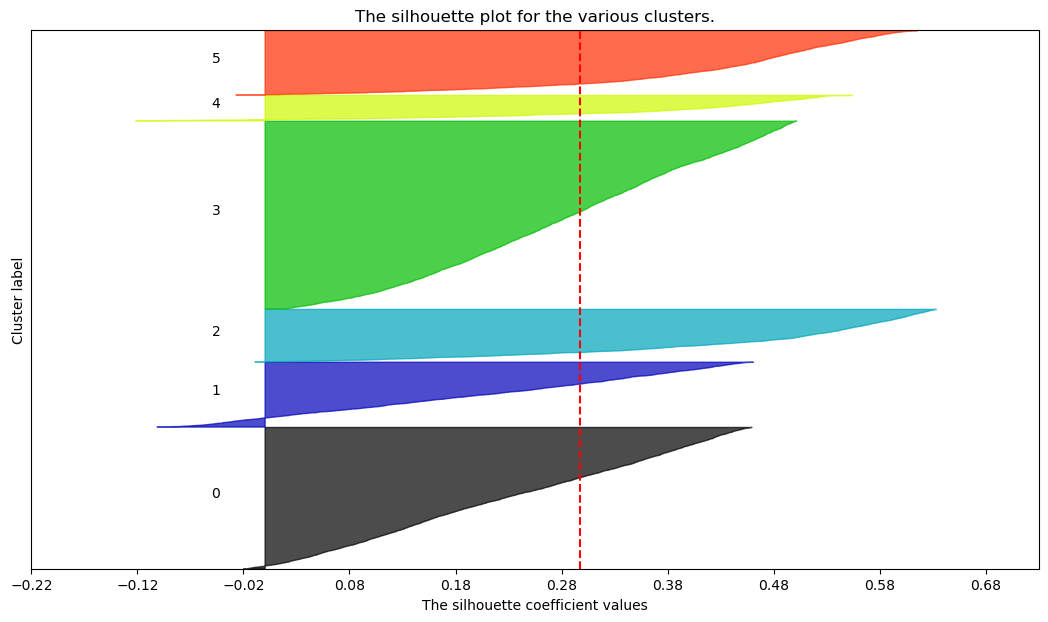

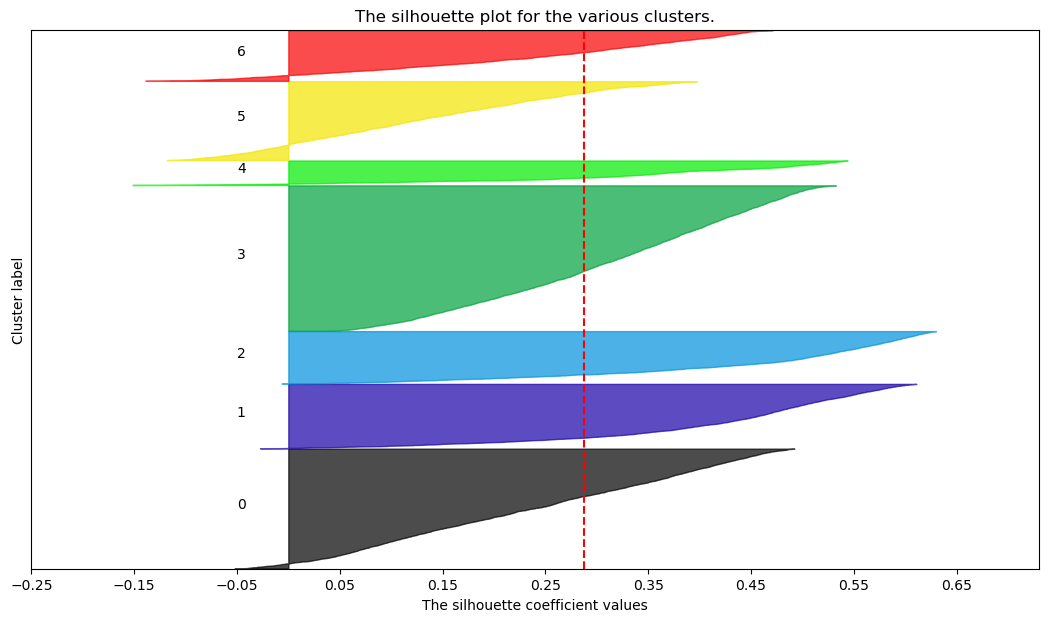

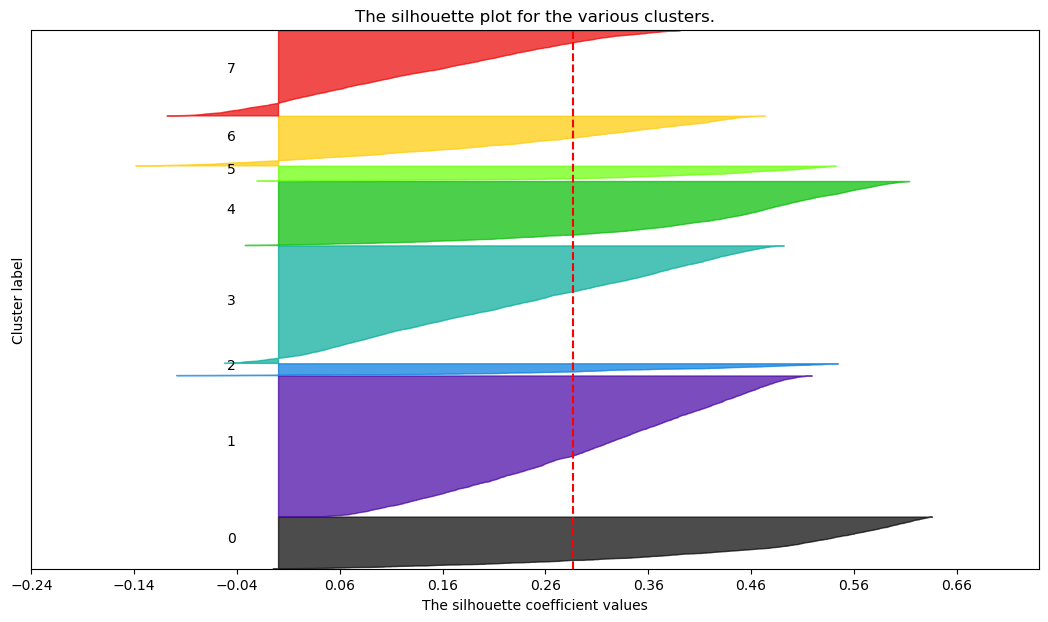

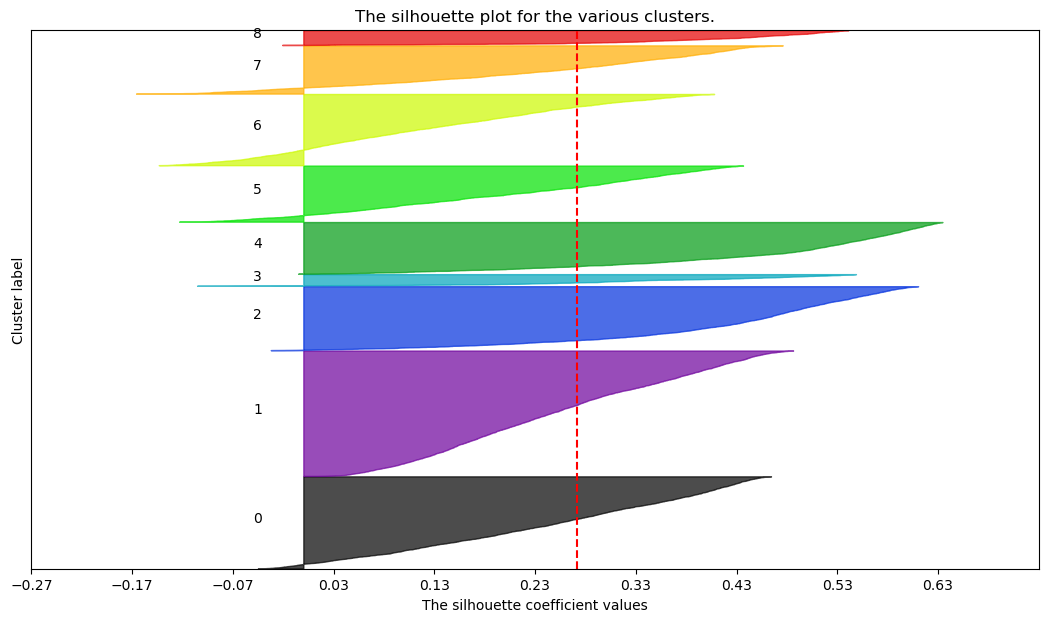

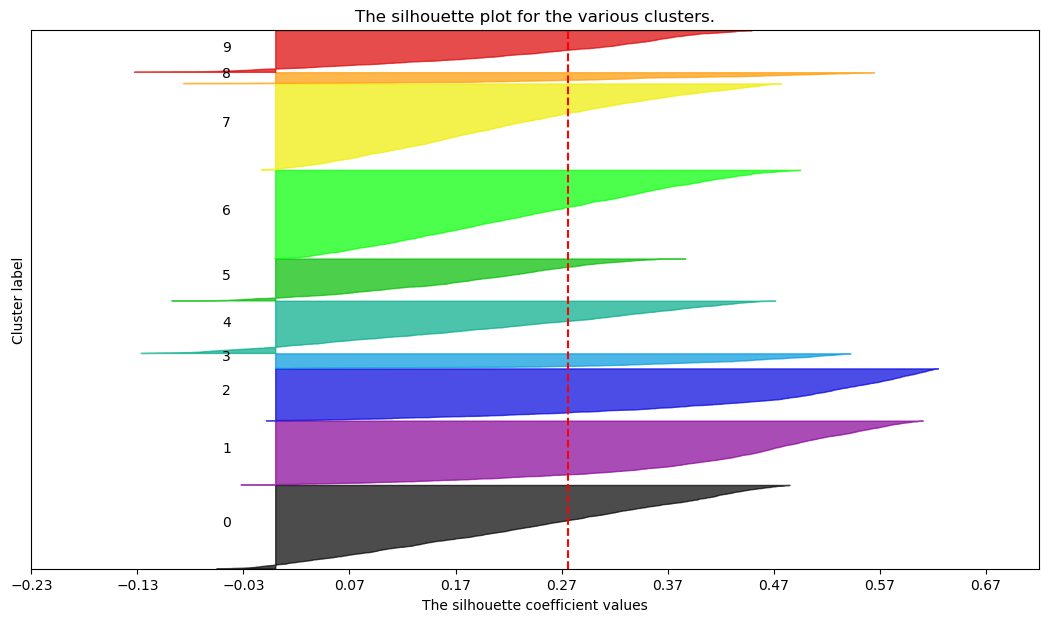

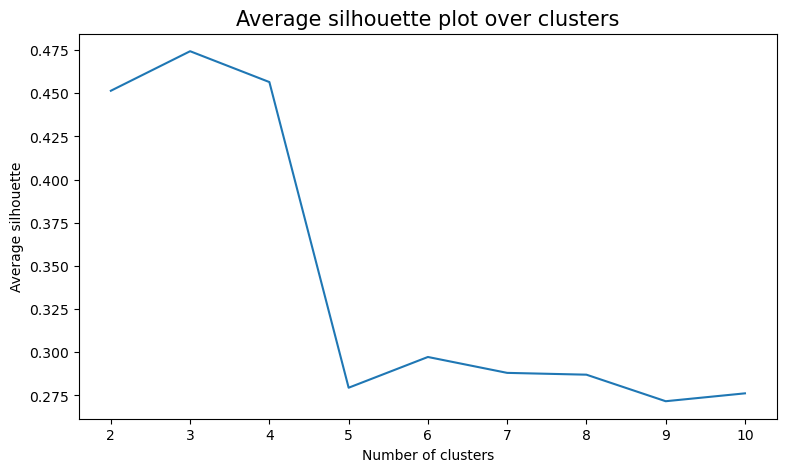

In [52]:
df = fe_df_scaled

df["last_active_month"] = pd.to_datetime(df["last_active_month"])

analysis_date = df["last_active_month"].max() + pd.offsets.MonthEnd(1)

df["recency"] = (analysis_date - df["last_active_month"]).dt.days


metric_features = [
    "customer_lifetime_value",
    "flights_per_month",
    "PointsAccumulated",
    "points_redeemed_band",
    "tenure_band"
]

range_clusters = range(1, 11)

inertia = []
for n_clus in range_clusters:
    kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust.fit(df[metric_features])
    inertia.append(kmclust.inertia_)

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters, inertia)
ax.set_xticks(range_clusters)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

avg_silhouette = []
for nclus in range_clusters:
    if nclus == 1:
        continue
    fig = plt.figure(figsize=(13, 7))

    kmclust = KMeans(n_clusters=nclus, init='k-means++', n_init=15, random_state=1)
    cluster_labels = kmclust.fit_predict(df[metric_features])

    silhouette_avg = silhouette_score(df[metric_features], cluster_labels)
    avg_silhouette.append(silhouette_avg)
    print(f"For n_clusters = {nclus}, the average silhouette_score is : {silhouette_avg}")

    sample_silhouette_values = silhouette_samples(df[metric_features], cluster_labels)

    y_lower = 10
    for i in range(nclus):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / nclus)
        plt.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10

    plt.title("The silhouette plot for the various clusters.")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")

    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    
    xmin, xmax = np.round(sample_silhouette_values.min() -0.1, 2), np.round(sample_silhouette_values.max() + 0.1, 2)
    plt.xlim([xmin, xmax])
    
    plt.ylim([0, len(df[metric_features]) + (nclus + 1) * 10])

    plt.yticks([])  # Clear the yaxis labels / ticks
    plt.xticks(np.arange(xmin, xmax, 0.1))

plt.figure(figsize=(9,5))


plt.plot(range_clusters[1:],
         avg_silhouette)

plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters")
plt.title("Average silhouette plot over clusters", size=15)
plt.show()

### Conclusion: K-Means Clustering

K-Means was tested across multiple cluster sizes using both the inertia curve and silhouette analysis in the PCA space. The goal here was not just to maximize a metric, but to find a clustering solution that makes sense from a **value-based customer perspective**.

The inertia plot shows a clear elbow around **4 clusters**. Beyond this point, the reduction in within-cluster variance becomes marginal, indicating that increasing the number of clusters adds complexity without meaningful gains.

Silhouette scores are highest for very small values of *k* (2–3 clusters), but these solutions are overly simplistic and collapse customers into broad groups that do not reflect meaningful differences in customer value. At **4 clusters**, the average silhouette score remains reasonably strong, and more importantly, the silhouette plots show mostly positive values with acceptable separation between clusters.

As *k* increases beyond 4, the average silhouette score steadily declines and the clusters become thinner and more fragmented. This suggests over-segmentation, where customers are being split into smaller groups without clear value-driven justification.

From a practical standpoint, **4 clusters provide the best balance** between statistical quality and business interpretability. The clusters are distinct enough to capture differences in customer value, while still being stable and easy to reason about.

**Final decision:**  
K-Means with **4 clusters** was selected as the final configuration, as it offers a sensible, interpretable, and value-aligned segmentation rather than an over-engineered solution driven purely by metrics.


In [53]:
kmclust4 = KMeans(n_clusters=4, init='k-means++', n_init=15, random_state=1)
kmclust4.fit(df[metric_features])
kmclabels4 = kmclust4.predict(df[metric_features])

df_concat4 = pd.concat((df[metric_features], pd.Series(kmclabels4, name='labels', index=df.index)), axis=1)
df_concat4.groupby('labels').mean()

,customer_lifetime_value,flights_per_month,PointsAccumulated,points_redeemed_band,tenure_band
labels,,,,,
0,0.104280,0.109156,0.115394,-0.152665,-0.214572
1,0.082833,0.100221,0.006850,-3.000000,-0.292458
2,0.108135,-1.673556,-1.522660,-2.552792,-1.049751
3,0.096032,3.114901,-1.074995,-1.764535,-2.805233


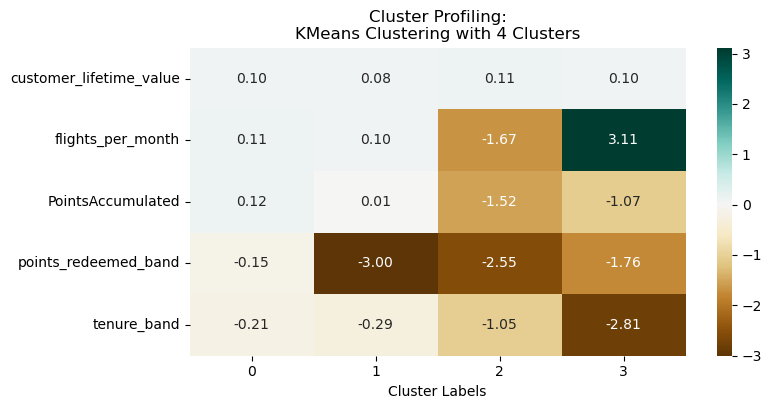

In [54]:
fig, ax = plt.subplots(figsize=(8,4))

km_profile = df_concat4.groupby('labels').mean().T

sns.heatmap(km_profile,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 4 Clusters")
plt.show()

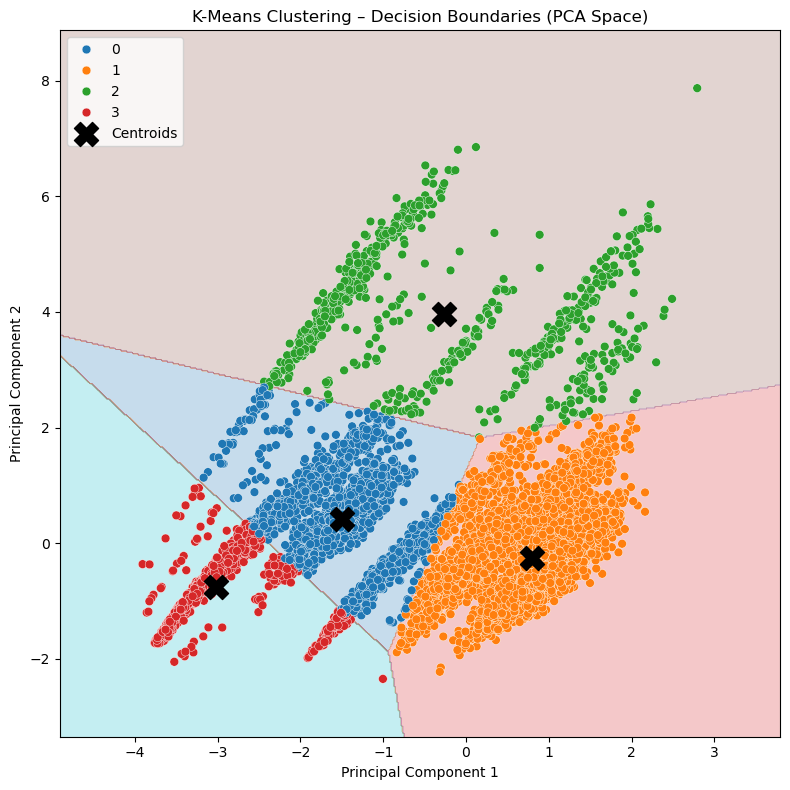

In [55]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df[metric_features])

kmeans_pca = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=20,
    random_state=42
)
labels_pca = kmeans_pca.fit_predict(X_pca)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = kmeans_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 8))

# Decision boundaries
ax.contourf(
    xx, yy, Z,
    alpha=0.25,
    cmap="tab10"
)

# Data points
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_pca,
    palette="tab10",
    s=40,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

# Centroids
ax.scatter(
    kmeans_pca.cluster_centers_[:, 0],
    kmeans_pca.cluster_centers_[:, 1],
    s=300,
    c="black",
    marker="X",
    label="Centroids"
)

ax.set_title("K-Means Clustering – Decision Boundaries (PCA Space)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend()

plt.tight_layout()
plt.show()

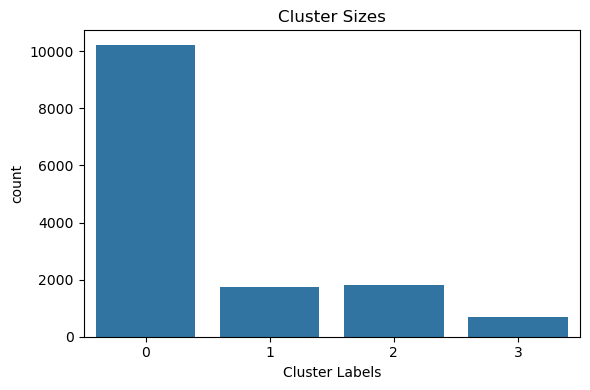

In [56]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df_concat4, x='labels')
ax.set_title("Cluster Sizes")
ax.set_xlabel("Cluster Labels")
fig.tight_layout()
plt.show()

## Hierarchical Clustering

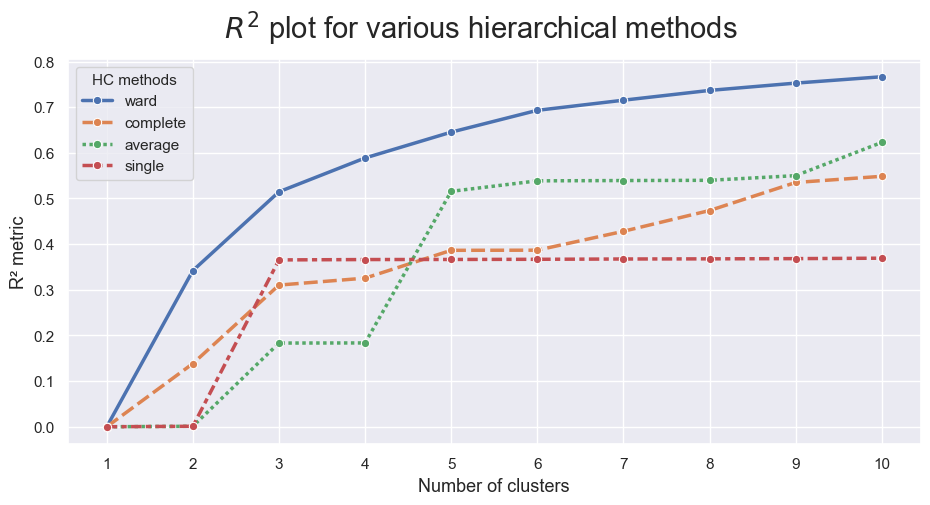

In [57]:
value_features = [
    "customer_lifetime_value",
    "flights_per_month",
    "PointsAccumulated",
    "points_redeemed_band",
    "tenure_band"
]

feats = value_features

def get_ss(df, feats):
    df_ = df[feats]
    return np.sum(df_.var() * (df_.count() - 1))


def get_ssb(df, feats, label_col):
    ssb_i = 0
    X_ = df[feats].values
    X_mean = X_.mean(axis=0)

    for i in np.unique(df[label_col]):
        X_k = df.loc[df[label_col] == i, feats].values
        ssb_i += X_k.shape[0] * np.square(X_k.mean(axis=0) - X_mean)

    return np.sum(ssb_i)


def get_ssw(df, feats, label_col):
    feats_label = feats + [label_col]
    df_k = (
        df[feats_label]
        .groupby(label_col)
        .apply(lambda x: get_ss(x, feats), include_groups=False)
    )
    return df_k.sum()


def get_rsq(df, feats, label_col):
    sst = get_ss(df, feats)
    ssw = get_ssw(df, feats, label_col)
    ssb = sst - ssw
    return ssb / sst


def get_r2_hc(df, link_method, max_nclus, min_nclus=1, dist="euclidean"):
    r2 = []
    feats = df.columns.tolist()

    for k in range(min_nclus, max_nclus + 1):
        hc = AgglomerativeClustering(
            n_clusters=k,
            metric=dist,
            linkage=link_method
        )

        labels = hc.fit_predict(df)

        df_labeled = df.copy()
        df_labeled["labels"] = labels

        r2.append(get_rsq(df_labeled, feats, "labels"))

    return np.array(r2)


hc_methods = ["ward", "complete", "average", "single"]
max_nclus = 10

X = df[value_features]

r2_hc = np.vstack([
    get_r2_hc(
        X,
        link_method=link,
        max_nclus=max_nclus,
        min_nclus=1,
        dist="euclidean"
    )
    for link in hc_methods
])

r2_hc_methods = pd.DataFrame(
    r2_hc.T,
    index=range(1, max_nclus + 1),
    columns=hc_methods
)

sns.set()

fig = plt.figure(figsize=(11, 5))
sns.lineplot(data=r2_hc_methods, linewidth=2.5, markers=["o"] * len(hc_methods))

plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R² metric", fontsize=13)

fig.suptitle("$R^2$ plot for various hierarchical methods", fontsize=21)

plt.show()


### Conclusion: Hierarchical Clustering

For hierarchical clustering, multiple linkage methods were analyzed using the R² plot to understand how much structure each method captures as the number of clusters increases. The goal was to find a solution that explains enough variance without unnecessarily fragmenting the customer base.

Across all methods, **Ward linkage clearly performs the best**. It shows a strong increase in explained variance up to **4 clusters**, after which the curve starts to flatten. This indicates that most of the meaningful structure in the data is already captured by this point.

Beyond 4 clusters, the gains in R² are relatively small. Additional clusters mostly split existing groups instead of revealing new, value-relevant segments. This is especially clear when compared to other methods:
- **Complete** and **Average** linkage improve more slowly and remain less stable
- **Single** linkage plateaus early and is not suitable for value-based segmentation

From a practical and value-based perspective, increasing the number of clusters beyond 4 adds complexity without clear benefits.

**Final decision:**  
Hierarchical clustering with **4 clusters using Ward linkage** was selected, as it provides a clean, stable, and interpretable segmentation that aligns well with the underlying customer value structure.


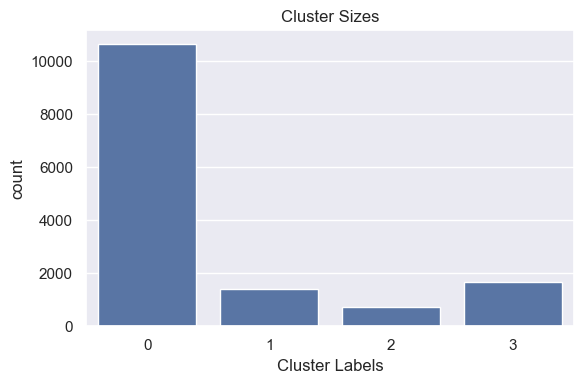

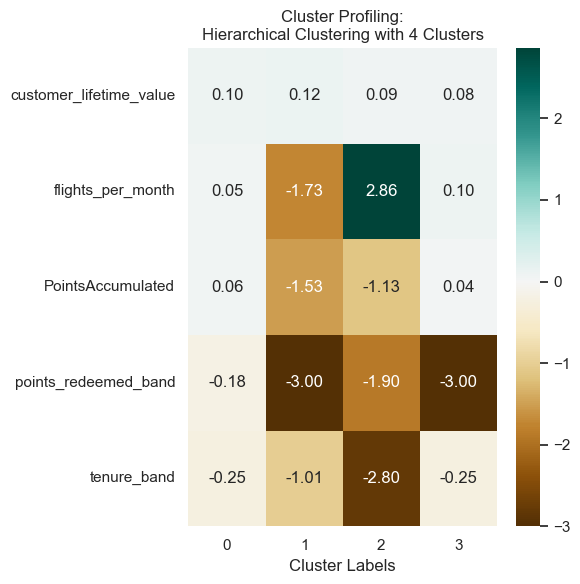

In [58]:
hclust4= AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=4)
hc_labels4 = hclust4.fit_predict(df[value_features])

labels_series = pd.Series(hc_labels4, name='labels', index=df.index)

df_concat4 = pd.concat([df[value_features], labels_series],axis=1)
df_concat4[value_features+['labels']].groupby('labels').mean()

fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df_concat4, x='labels')
ax.set_title("Cluster Sizes")
ax.set_xlabel("Cluster Labels")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
hc_profile = df_concat4.groupby('labels').mean().T
sns.heatmap(hc_profile,center=0, annot=True, cmap="BrBG", fmt=".2f",ax=ax)
ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nHierarchical Clustering with 4 Clusters")
fig.tight_layout()
plt.show()

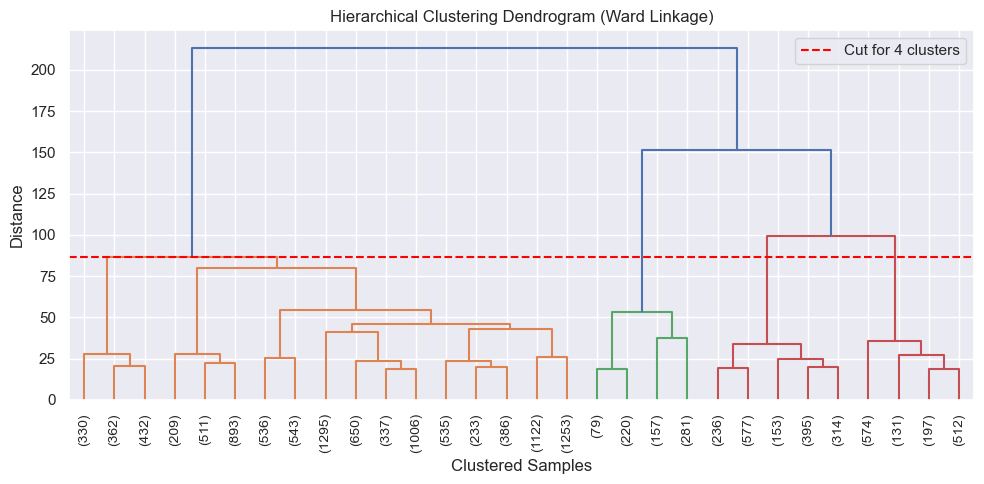

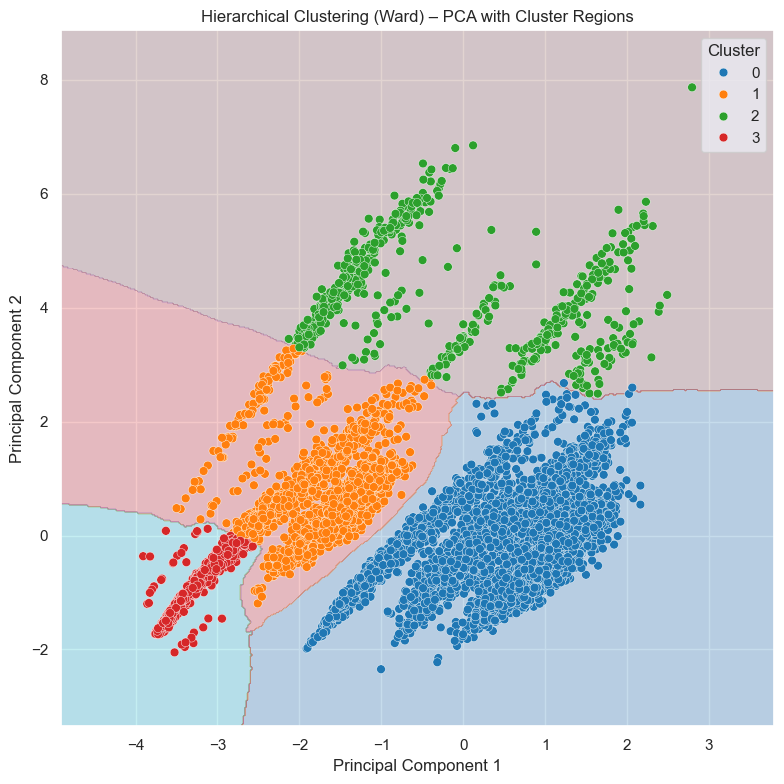

In [59]:
Z = linkage(df[value_features], method="ward")

plt.figure(figsize=(10, 5))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.axhline(y=Z[-4, 2], color="red", linestyle="--", label="Cut for 4 clusters")
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Clustered Samples")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df[value_features])

hc = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward",
    metric="euclidean"
)
hc_labels = hc.fit_predict(X_pca)

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_pca, hc_labels)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z_region = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_region = Z_region.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 8))

ax.contourf(
    xx, yy, Z_region,
    alpha=0.25,
    cmap="tab10"
)

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=hc_labels,
    palette="tab10",
    s=40,
    edgecolor="white",
    linewidth=0.3,
    ax=ax
)

ax.set_title("Hierarchical Clustering (Ward) – PCA with Cluster Regions")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(title="Cluster")

plt.tight_layout()
plt.show()

In [60]:
pd.crosstab(
    pd.Series(hc_labels4, name='HC6', index=df.index),
    pd.Series(kmclabels4, name='KM4', index=df.index)
    )

KM4,0,1,2,3
HC6,,,,
0,10222,0,395,16
1,0,71,1343,0
2,3,14,50,670
3,0,1652,21,2


## RFM

In [61]:
rfm_df = fe_df_scaled.copy()

rfm_df["last_active_month"] = pd.to_datetime(rfm_df["last_active_month"])

analysis_date = rfm_df["last_active_month"].max() + pd.offsets.MonthEnd(1)

rfm_df["recency"] = (analysis_date - rfm_df["last_active_month"]).dt.days

rfm_df["frequency"] = rfm_df["flights_per_month"]

rfm_df["monetary"] = rfm_df["PointsAccumulated"]

rfm_df["R_score"] = pd.qcut(
    rfm_df["recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm_df["F_score"] = pd.qcut(
    rfm_df["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm_df["M_score"] = pd.qcut(
    rfm_df["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm_df["RFM_score"] = (
    rfm_df["R_score"].astype(int) +
    rfm_df["F_score"].astype(int) +
    rfm_df["M_score"].astype(int)
)

rfm_df["RFM_code"] = (
    rfm_df["R_score"].astype(str) +
    rfm_df["F_score"].astype(str) +
    rfm_df["M_score"].astype(str)
)

def rfm_segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 10:
        return "Loyal"
    elif score >= 7:
        return "Potential Loyalists"
    elif score >= 5:
        return "At Risk"
    else:
        return "Lost"

rfm_df["segment"] = rfm_df["RFM_score"].apply(rfm_segment)


rfm = rfm_df[[
    "Loyalty#",
    "recency",
    "frequency",
    "monetary",
    "R_score",
    "F_score",
    "M_score",
    "RFM_score",
    "RFM_code",
    "segment"
]].copy()

rfm.head()

,Loyalty#,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_code,segment
0,100018,30,0.968515,1.046348,5,5,5,15,555,Champions
1,100102,30,0.204945,-0.037713,5,4,3,12,543,Loyal
2,100140,30,0.821712,0.489197,5,5,5,15,555,Champions
3,100214,30,-0.733266,0.106929,5,1,3,9,513,Potential Loyalists
4,100272,30,-0.170192,0.475621,5,3,4,12,534,Loyal


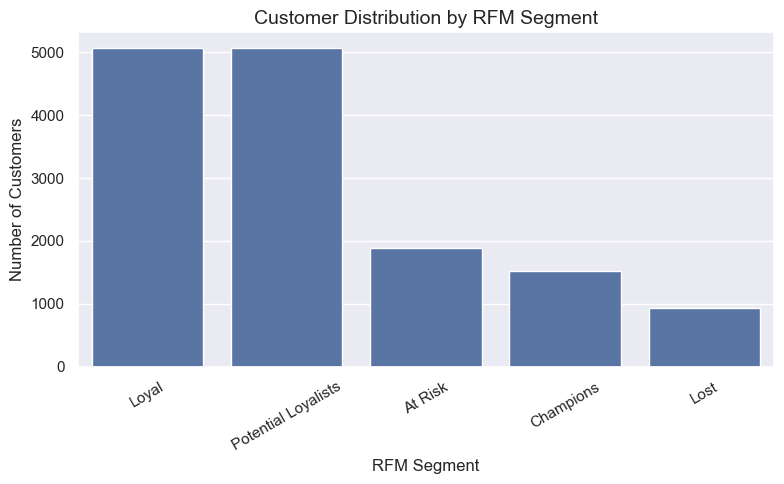

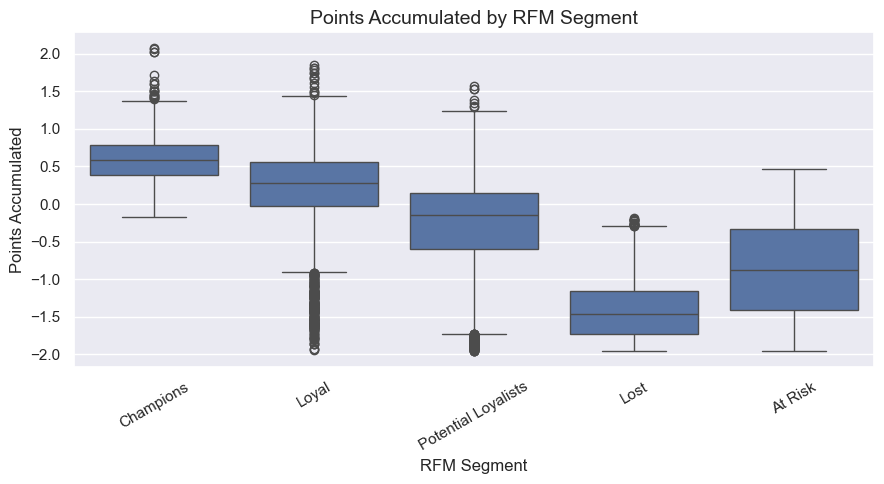

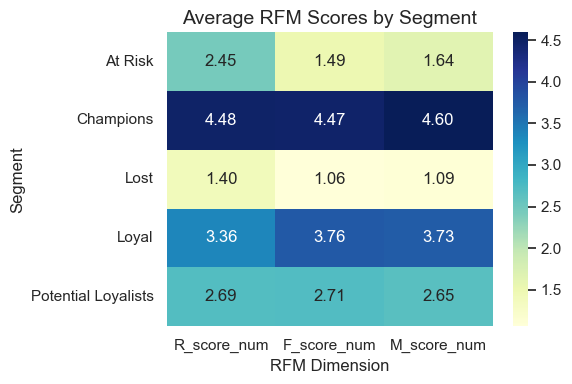

In [62]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=rfm,
    x="segment",
    order=rfm["segment"].value_counts().index
)
plt.title("Customer Distribution by RFM Segment", fontsize=14)
plt.xlabel("RFM Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=rfm,
    x="segment",
    y="monetary"
)
plt.title("Points Accumulated by RFM Segment", fontsize=14)
plt.xlabel("RFM Segment")
plt.ylabel("Points Accumulated")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

rfm_summary = (
    rfm.assign(
        R_score_num=rfm["R_score"].astype(int),
        F_score_num=rfm["F_score"].astype(int),
        M_score_num=rfm["M_score"].astype(int)
    )
    .groupby("segment")[["R_score_num", "F_score_num", "M_score_num"]]
    .mean()
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    rfm_summary,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)
plt.title("Average RFM Scores by Segment", fontsize=14)
plt.xlabel("RFM Dimension")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()


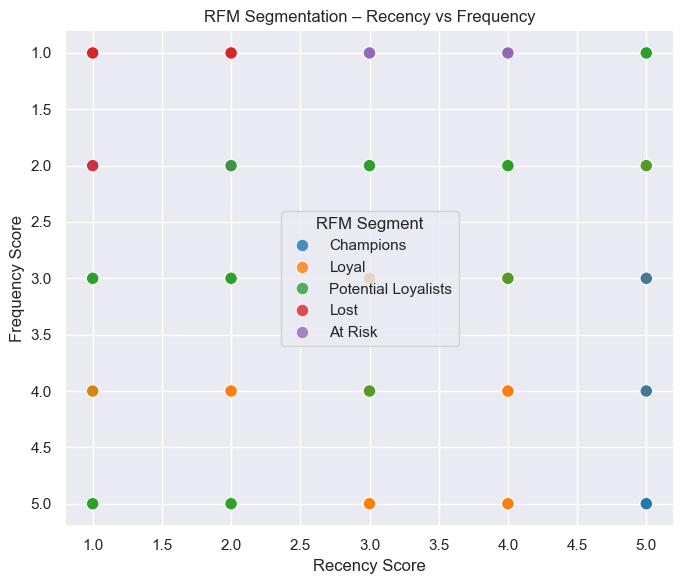

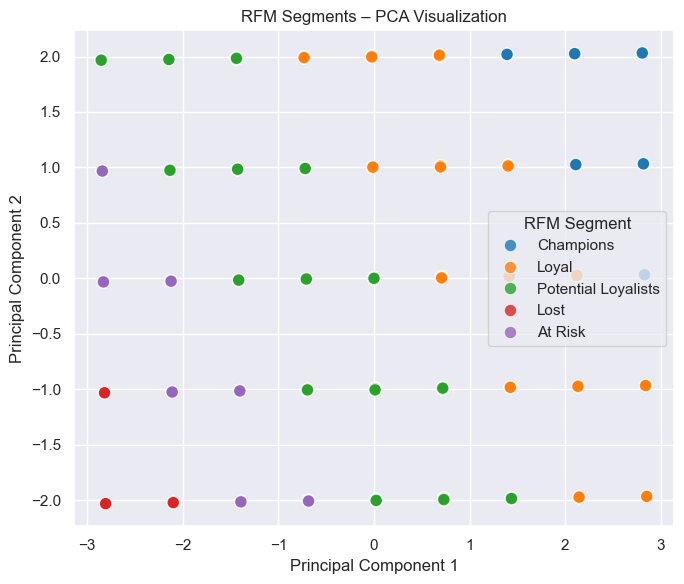

In [63]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=rfm,
    x="R_score",
    y="F_score",
    hue="segment",
    palette="tab10",
    s=80,
    alpha=0.8,
    ax=ax
)
ax.set_title("RFM Segmentation – Recency vs Frequency")
ax.set_xlabel("Recency Score")
ax.set_ylabel("Frequency Score")
ax.legend(title="RFM Segment")
plt.tight_layout()
plt.show()

X_rfm = rfm[["R_score", "F_score", "M_score"]]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_rfm)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=rfm.index
)
pca_df["segment"] = rfm["segment"]

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="segment",
    palette="tab10",
    s=80,
    alpha=0.8,
    ax=ax
)
ax.set_title("RFM Segments – PCA Visualization")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(title="RFM Segment")
plt.tight_layout()
plt.show()

### Conclusion: RFM Segmentation

RFM segmentation provides the clearest and most business-aligned view of customer value in this dataset. Unlike purely distance-based clustering methods, RFM directly captures **recency, frequency, and monetary contribution**, which makes the resulting segments immediately interpretable.

The customer distribution shows that the majority of customers fall into the **Loyal** and **Potential Loyalists** segments. These groups represent a stable base with consistent engagement and moderate to high value, making them critical for retention-focused strategies. The **Champions** segment, while smaller in size, stands out as the highest-value group, contributing the most in terms of frequency and monetary value.

The points accumulation analysis reinforces this structure. **Champions and Loyal customers** consistently accumulate higher points, while **At Risk** and **Lost** customers show significantly lower accumulation, indicating declining engagement and reduced economic contribution.

This pattern is further confirmed by the average RFM scores. **Champions** score highest across all three dimensions, followed by **Loyal** customers. **Potential Loyalists** sit in the middle, representing a clear opportunity segment, while **At Risk** and **Lost** customers show low scores across dimensions, validating their classification.

Overall, RFM produces well-separated, intuitive segments that align closely with customer value and lifecycle stages.

**Final takeaway:**  
RFM delivers the most actionable segmentation in this analysis, clearly distinguishing high-value customers from those requiring re-engagement or churn-prevention strategies, and serves as a strong benchmark against which the algorithmic clustering results can be evaluated.


## Value Based Segmentation Conclusions:
While multiple unsupervised clustering techniques were evaluated, the analysis indicates that customer value in the dataset varies continuously rather than forming strongly separated natural clusters. As a result, distance-based clustering methods such as KMeans and hierarchical clustering yielded weak separation. In contrast, RFM-based segmentation provided stable, interpretable, and business-relevant value tiers, making it the most appropriate approach for value-based customer segmentation in this context.